In [1]:
!pip install ftfy pandas chromadb tqdm deep-translator langdetect sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 21.5 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 62.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 71.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 

In [2]:
import re
import os
import time
import ftfy                        # fixes mojibake / encoding artifacts
import pandas as pd
import chromadb
from tqdm.auto import tqdm
from deep_translator import GoogleTranslator
from langdetect import detect, LangDetectException
from sentence_transformers import SentenceTransformer
 
 
# ============================================================
# 0.  INSTALL GUARD  (run once in Kaggle)
# ============================================================
# !pip install ftfy langdetect deep-translator sentence-transformers chromadb -q
 
 
# ============================================================
# 1.  LOAD  — try multiple encodings so ??? never happens
# ============================================================
 
def load_recipe_csv(path: str) -> pd.DataFrame:
    """
    Try encodings in order until the file loads cleanly.
    ftfy then repairs any remaining mojibake at the cell level.
    """
    encodings = ["utf-8", "utf-8-sig", "cp1252", "iso-8859-1", "latin-1"]
    df = None
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"✅ Loaded with encoding: {enc}  — {len(df)} rows")
            break
        except (UnicodeDecodeError, pd.errors.ParserError):
            continue
 
    if df is None:
        # Last resort: read bytes, replace bad chars, then parse
        with open(path, "rb") as f:
            raw = f.read().decode("utf-8", errors="replace")
        from io import StringIO
        df = pd.read_csv(StringIO(raw))
        print(f"⚠️  Loaded with errors='replace'  — {len(df)} rows")
 
    # Apply ftfy on every string column to fix remaining mojibake
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].apply(lambda x: ftfy.fix_text(str(x)) if pd.notna(x) else x)
 
    return df
 
 
# ============================================================
# 2.  DETECT & TRANSLATE  (Hindi → English)
# ============================================================
 
# Cache so we don't re-translate the same string in different rows
_translation_cache: dict[str, str] = {}
 
def _is_hindi(text: str) -> bool:
    """
    Two-stage check:
      1. Fast regex — Devanagari Unicode block (U+0900–U+097F)
      2. langdetect fallback for romanised Hindi / mixed scripts
    """
    if not text or not isinstance(text, str):
        return False
    # Any Devanagari character → definitely Hindi/Sanskrit
    if re.search(r'[\u0900-\u097F]', text):
        return True
    # Unreadable ??? artifacts — these are broken Devanagari
    if text.count('?') / max(len(text), 1) > 0.3:
        return True
    return False
 
 
def translate_to_english(text: str, retries: int = 3) -> str:
    """
    Translate a single string to English using GoogleTranslator.
    Returns original text if translation fails or isn't needed.
    """
    if not text or not isinstance(text, str):
        return text
    text = text.strip()
    if not _is_hindi(text):
        return text
    if text in _translation_cache:
        return _translation_cache[text]
 
    for attempt in range(retries):
        try:
            translated = GoogleTranslator(source="auto", target="en").translate(text)
            result = translated if translated else text
            _translation_cache[text] = result
            return result
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)   # exponential back-off: 1s, 2s, 4s
            else:
                print(f"    ⚠️  Translation failed after {retries} attempts: {e}")
                _translation_cache[text] = text
                return text
 
 
def translate_column(series: pd.Series, col_name: str) -> pd.Series:
    """Translate an entire Series with a progress bar."""
    print(f"  Translating column: {col_name}")
    results = []
    hindi_count = 0
    for val in tqdm(series, desc=f"  {col_name}", leave=False):
        if _is_hindi(str(val)):
            hindi_count += 1
            results.append(translate_to_english(str(val)))
        else:
            results.append(val)
    print(f"    → {hindi_count} Hindi values translated in '{col_name}'")
    return pd.Series(results, index=series.index)
 
 
# ============================================================
# 3.  FIELD-LEVEL CLEANING
# ============================================================
 
# --- Ingredients ---
 
def clean_ingredients(raw: str) -> str:
    """
    Input:  "1 cup rice,2 tsp oil,salt - to taste"
    Output: "1 cup rice, 2 tsp oil, salt"
    """
    if not raw or not isinstance(raw, str):
        return ""
    raw = raw.strip()
 
    # Split on commas
    parts = [p.strip() for p in raw.split(",") if p.strip()]
    cleaned = []
    for part in parts:
        # Remove "- to taste", "- as needed", "- for garnish" suffixes
        part = re.sub(r'\s*-\s*(to taste|as needed|as required|for garnish|'
                      r'for seasoning|adjust to taste)', '', part, flags=re.I)
        # Normalise whitespace
        part = re.sub(r'\s+', ' ', part).strip()
        # Drop empty or single-char fragments
        if len(part) > 1:
            cleaned.append(part)
 
    return ", ".join(cleaned)
 
 
# --- Instructions ---
 
def clean_instructions(raw: str) -> str:
    """
    Strips HTML tags, excessive whitespace, and truncates very long
    instructions to 1000 chars (embedding models have token limits).
    """
    if not raw or not isinstance(raw, str):
        return ""
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', raw)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Truncate — keep first 1000 chars (roughly 200 tokens)
    return text[:1000]
 
 
# --- Recipe name ---
 
def clean_recipe_name(raw: str) -> str:
    if not raw or not isinstance(raw, str):
        return "Unknown Recipe"
    name = raw.strip()
    # Remove leading index numbers like "13994  Tadkewali..."
    name = re.sub(r'^\d+\s+', '', name)
    # Title-case
    return name.strip().title()
 
 
# --- Numeric fields ---
 
def clean_numeric(val, default: int = 0) -> int:
    try:
        return int(float(str(val).strip()))
    except (ValueError, TypeError):
        return default
 
 
# --- Diet / Cuisine / Course normalisation ---
 
DIET_ALIASES = {
    "high protein vegetarian": "High Protein Vegetarian",
    "vegetarian":              "Vegetarian",
    "vegan":                   "Vegan",
    "non vegetarian":          "Non Vegetarian",
    "eggetarian":              "Eggetarian",
    "diabetic friendly":       "Diabetic Friendly",
    "gluten free":             "Gluten Free",
    "no onion no garlic":      "No Onion No Garlic",
    "sugar free diet":         "Sugar Free",
    "high fiber vegetarian":   "High Fiber Vegetarian",
    "":                        "Unspecified",
}
 
def normalise_diet(raw: str) -> str:
    key = str(raw).strip().lower()
    return DIET_ALIASES.get(key, str(raw).strip().title())
 
 
# ============================================================
# 4.  MASTER CLEANING FUNCTION
# ============================================================
 
REQUIRED_COLS = [
    "TranslatedRecipeName",
    "TranslatedIngredients",
    "TranslatedInstructions",
    "Cuisine",
    "Course",
    "Diet",
    "Servings",
    "PrepTimeInMins",
    "CookTimeInMins",
    "TotalTimeInMins",
]
 
def clean_recipe_df(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Full cleaning pipeline:
      1. Column standardisation
      2. Drop rows with no usable content
      3. Translate Hindi fields
      4. Field-level cleaning
      5. Deduplication
    """
    print("\n" + "="*60)
    print("STEP 1/5 — Column standardisation")
    print("="*60)
 
    df = raw_df.copy()
 
    # Rename Srno → index if present
    if "Srno" in df.columns:
        df = df.rename(columns={"Srno": "original_index"})
 
    # Ensure all required columns exist
    for col in REQUIRED_COLS:
        if col not in df.columns:
            print(f"  ⚠️  Missing column '{col}' — filling with empty string")
            df[col] = ""
 
    # Fill NaN
    df = df.fillna("")
 
    print(f"  Rows loaded: {len(df)}")
 
    # ── Step 2: Drop unusable rows ──────────────────────────────────────
    print("\n" + "="*60)
    print("STEP 2/5 — Dropping unusable rows")
    print("="*60)
 
    before = len(df)
 
    # Must have a recipe name
    df = df[df["TranslatedRecipeName"].str.strip().str.len() > 2]
 
    # Must have at least some ingredients
    df = df[df["TranslatedIngredients"].str.strip().str.len() > 5]
 
    # Rows where >50% of ingredient text is '?' are broken-encoding rows
    def is_mostly_garbage(text: str) -> bool:
        if not text:
            return False
        q_ratio = text.count('?') / max(len(text), 1)
        return q_ratio > 0.4
 
    # Flag broken rows — we'll translate these rather than drop them
    df["_has_hindi"] = (
        df["TranslatedIngredients"].apply(_is_hindi) |
        df["TranslatedRecipeName"].apply(_is_hindi) |
        df["TranslatedInstructions"].apply(_is_hindi)
    )
 
    garbage_mask = df["TranslatedIngredients"].apply(is_mostly_garbage)
    df_garbage = df[garbage_mask & ~df["_has_hindi"]]   # broken AND not translatable
    df = df[~garbage_mask | df["_has_hindi"]]           # keep translatable ones
 
    print(f"  Rows dropped (unrecoverable garbage): {len(df_garbage)}")
    print(f"  Rows with Hindi content to translate:  {df['_has_hindi'].sum()}")
    print(f"  Rows remaining: {len(df)}  (dropped {before - len(df)} total)")
 
    # ── Step 3: Translate Hindi ─────────────────────────────────────────
    print("\n" + "="*60)
    print("STEP 3/5 — Hindi → English translation")
    print("="*60)
 
    translate_cols = [
        "TranslatedRecipeName",
        "TranslatedIngredients",
        "TranslatedInstructions",
    ]
 
    for col in translate_cols:
        df[col] = translate_column(df[col], col)
 
    df = df.drop(columns=["_has_hindi"])
 
    # ── Step 4: Field-level cleaning ────────────────────────────────────
    print("\n" + "="*60)
    print("STEP 4/5 — Field-level cleaning")
    print("="*60)
 
    df["TranslatedRecipeName"]    = df["TranslatedRecipeName"].apply(clean_recipe_name)
    df["TranslatedIngredients"]   = df["TranslatedIngredients"].apply(clean_ingredients)
    df["TranslatedInstructions"]  = df["TranslatedInstructions"].apply(clean_instructions)
    df["Diet"]                    = df["Diet"].apply(normalise_diet)
    df["Cuisine"]                 = df["Cuisine"].str.strip().str.title()
    df["Course"]                  = df["Course"].str.strip().str.title()
    df["Servings"]                = df["Servings"].apply(lambda x: clean_numeric(x, default=4))
    df["PrepTimeInMins"]          = df["PrepTimeInMins"].apply(lambda x: clean_numeric(x, default=0))
    df["CookTimeInMins"]          = df["CookTimeInMins"].apply(lambda x: clean_numeric(x, default=0))
    df["TotalTimeInMins"]         = df["TotalTimeInMins"].apply(lambda x: clean_numeric(x, default=0))
 
    # Recompute TotalTime if it's 0 but Prep+Cook are known
    mask = (df["TotalTimeInMins"] == 0) & (df["PrepTimeInMins"] + df["CookTimeInMins"] > 0)
    df.loc[mask, "TotalTimeInMins"] = df.loc[mask, "PrepTimeInMins"] + df.loc[mask, "CookTimeInMins"]
 
    # Drop rows where ingredients are now empty after cleaning
    df = df[df["TranslatedIngredients"].str.strip().str.len() > 5]
 
    print(f"  Rows after field cleaning: {len(df)}")
 
    # ── Step 5: Deduplication ───────────────────────────────────────────
    print("\n" + "="*60)
    print("STEP 5/5 — Deduplication")
    print("="*60)
 
    before_dedup = len(df)
    # Exact name + ingredient duplicates
    df = df.drop_duplicates(
        subset=["TranslatedRecipeName", "TranslatedIngredients"],
        keep="first"
    )
    df = df.reset_index(drop=True)
    print(f"  Duplicates removed: {before_dedup - len(df)}")
    print(f"  ✅ Final clean dataset: {len(df)} recipes")
 
    return df
 
 
# ============================================================
# 5.  EMBEDDING TEXT CONSTRUCTION
# ============================================================
 
def build_embedding_text(row: pd.Series) -> str:
    """
    Constructs a rich, structured string for embedding.
    Weights the recipe name and ingredients more heavily by repeating them,
    since these are the most semantically important fields for retrieval.
 
    Example output:
        "Tadka Dal. Ingredients: red lentils, cumin, turmeric, garlic, ghee,
         tomato, onion. Diet: High Protein Vegetarian. Cuisine: North Indian.
         Course: Lunch. Ready in 30 minutes. Serves 4."
    """
    name        = str(row.get("TranslatedRecipeName", "")).strip()
    ingredients = str(row.get("TranslatedIngredients", "")).strip()
    diet        = str(row.get("Diet", "")).strip()
    cuisine     = str(row.get("Cuisine", "")).strip()
    course      = str(row.get("Course", "")).strip()
    total_time  = clean_numeric(row.get("TotalTimeInMins", 0))
    servings    = clean_numeric(row.get("Servings", 4))
 
    # Shorten ingredients list for embedding — first 15 items only
    # (avoids token overflow; the full list is stored in metadata)
    short_ingredients = ", ".join(
        [i.strip() for i in ingredients.split(",")][:15]
    )
 
    parts = [
        f"{name}.",                                    # name first (most important)
        f"Ingredients: {short_ingredients}.",
    ]
    if diet:        parts.append(f"Diet: {diet}.")
    if cuisine:     parts.append(f"Cuisine: {cuisine}.")
    if course:      parts.append(f"Course: {course}.")
    if total_time:  parts.append(f"Ready in {total_time} minutes.")
    if servings:    parts.append(f"Serves {servings}.")
 
    return " ".join(parts)
 
 
# ============================================================
# 6.  CHROMADB SETUP
# ============================================================
 
def setup_chromadb(
    recipe_df: pd.DataFrame,
    chroma_path: str = "./chroma_db",
    collection_name: str = "indian_recipes",
    model_name: str = "all-MiniLM-L6-v2",
    batch_size: int = 2000,
) -> tuple[chromadb.PersistentClient, chromadb.Collection]:
    """
    Embeds the cleaned recipe DataFrame and indexes it into ChromaDB.
    Safe to re-run — always recreates the collection from scratch.
    """
    print("\n" + "="*60)
    print("CHROMADB INDEXING")
    print("="*60)
 
    # 1. Build embedding texts
    print("  Building embedding texts...")
    df = recipe_df.copy()
    df["embedding_text"] = df.apply(build_embedding_text, axis=1)
 
    # 2. Encode
    print(f"  Loading encoder: {model_name}")
    encoder = SentenceTransformer(model_name)
    print(f"  Encoding {len(df)} recipes...")
    embeddings = encoder.encode(
        df["embedding_text"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,   # unit vectors → cosine = dot product (faster)
    )
 
    # 3. Init ChromaDB
    chroma_client = chromadb.PersistentClient(path=chroma_path)
    try:
        chroma_client.delete_collection(collection_name)
        print(f"  🔄 Refreshed collection: {collection_name}")
    except Exception:
        print(f"  ✨ Creating new collection: {collection_name}")
 
    collection = chroma_client.create_collection(
        name=collection_name,
        metadata={"hnsw:space": "cosine"},
    )
 
    # 4. Prepare metadata — ChromaDB only accepts str/int/float/bool
    #    We keep only the fields Dishcovery actually queries on.
    METADATA_COLS = [
        "TranslatedRecipeName",
        "TranslatedIngredients",
        "Diet",
        "Cuisine",
        "Course",
        "Servings",
        "TotalTimeInMins",
        "PrepTimeInMins",
        "CookTimeInMins",
    ]
    meta_df = df[METADATA_COLS].copy()
 
    # Ensure no NaN/None in metadata (ChromaDB rejects them)
    for col in meta_df.select_dtypes(include="object").columns:
        meta_df[col] = meta_df[col].fillna("").astype(str)
    for col in meta_df.select_dtypes(include=["int64", "float64"]).columns:
        meta_df[col] = meta_df[col].fillna(0).astype(int)
 
    metadatas    = meta_df.to_dict("records")
    all_docs     = df["embedding_text"].tolist()
    all_embeddings = embeddings.tolist()
    all_ids      = [str(i) for i in range(len(df))]
 
    # 5. Batch insert
    total = len(all_ids)
    for i in range(0, total, batch_size):
        end = min(i + batch_size, total)
        collection.add(
            embeddings=all_embeddings[i:end],
            documents=all_docs[i:end],
            metadatas=metadatas[i:end],
            ids=all_ids[i:end],
        )
        print(f"  Indexed {end}/{total} recipes")
 
    print(f"\n✅ ChromaDB ready — {collection.count()} recipes indexed")
    return chroma_client, collection
 
 
# ============================================================
# 7.  RAG RETRIEVAL  (drop-in replacement for Dishcovery)
# ============================================================
 
def retrieve_similar_recipes(
    collection: chromadb.Collection,
    encoder: SentenceTransformer,
    query: str,
    dietary_restrictions: list[str] | None = None,
    n_results: int = 3,
) -> list[str]:
    """
    Retrieve top-N relevant recipes.
 
    Optionally filter by dietary tag so retrieved examples are always
    compliant — this makes the Sous Chef prompt more useful.
 
    Returns a list of embedding_text strings (what Gemini sees).
    """
    query_embedding = encoder.encode(
        [query], normalize_embeddings=True
    ).tolist()
 
    # Build a where-filter if dietary restrictions are provided
    where = None
    if dietary_restrictions:
        # Map our restriction tags to the Diet field values in the dataset
        diet_map = {
            "vegan":                  "Vegan",
            "vegetarian":             "Vegetarian",
            "gluten_free":            "Gluten Free",
            "no_onion_garlic":        "No Onion No Garlic",
            "high_protein":           "High Protein Vegetarian",
            "diabetic_friendly":      "Diabetic Friendly",
        }
        matched_diets = [
            diet_map[r] for r in dietary_restrictions if r in diet_map
        ]
        if matched_diets:
            # ChromaDB $in operator — filter to compliant diet rows only
            where = {"Diet": {"$in": matched_diets}}
 
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=n_results,
        where=where,
        include=["documents", "metadatas", "distances"],
    )
 
    docs      = results.get("documents", [[]])[0]
    distances = results.get("distances", [[]])[0]
    metas     = results.get("metadatas", [[]])[0]
 
    # Log retrieval quality
    print(f"\n  RAG retrieved {len(docs)} results for: '{query[:60]}'")
    for i, (doc, dist, meta) in enumerate(zip(docs, distances, metas)):
        print(f"    [{i+1}] {meta.get('TranslatedRecipeName', '?')} "
              f"| diet={meta.get('Diet','?')} "
              f"| similarity={1-dist:.3f}")
 
    return docs
 
 
# ============================================================
# 8.  DIAGNOSTIC  — run this to verify RAG is working
# ============================================================
 
def run_rag_diagnostic(collection: chromadb.Collection, encoder: SentenceTransformer):
    """
    Quick sanity checks to confirm retrieval is non-trivial.
    Prints similarity scores — you want these above 0.3 for good retrieval.
    """
    print("\n" + "="*60)
    print("RAG DIAGNOSTIC")
    print("="*60)
    print(f"  Total recipes indexed: {collection.count()}")
 
    test_queries = [
        ("vegan curry coconut milk spinach",         ["vegan"]),
        ("quick vegetarian dal lentils",             ["vegetarian"]),
        ("gluten free Indian flatbread rice flour",  ["gluten_free"]),
        ("butter chicken tomato cream",              None),
        ("paneer palak spinach",                     ["vegetarian"]),
    ]
 
    for query, restrictions in test_queries:
        print(f"\n  Query: '{query}' | restrictions: {restrictions}")
        retrieve_similar_recipes(
            collection, encoder, query,
            dietary_restrictions=restrictions,
            n_results=3,
        )
 
 
# ============================================================
# 9.  EXECUTION  (Kaggle cells)
# ============================================================
 
if __name__ == "__main__":
 
    # ── Cell 1: Load & Clean ─────────────────────────────────────────────
    # Point this at your Kaggle dataset path
    DATASET_PATH = "/kaggle/input/fooddataset/IndianFoodDatasetXLS.csv"
 
    raw_df    = load_recipe_csv(DATASET_PATH)
    clean_df  = clean_recipe_df(raw_df)
 
    # Optional: inspect a sample of previously-broken rows
    print("\nSample of cleaned rows (previously Hindi):")
    sample = clean_df[
        clean_df["TranslatedIngredients"].str.contains("lentil|dal|masoor", case=False, na=False)
    ].head(3)[["TranslatedRecipeName", "TranslatedIngredients", "Diet"]]
    print(sample.to_string())
 
    # ── Cell 2: Embed & Index ────────────────────────────────────────────
    encoder = SentenceTransformer("all-MiniLM-L6-v2")
    chroma_client, collection = setup_chromadb(clean_df)
 
    # ── Cell 3: Diagnostic ───────────────────────────────────────────────
    run_rag_diagnostic(collection, encoder)

2026-04-17 14:53:56.900912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776437637.142229      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776437637.213146      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776437637.783906      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776437637.783966      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776437637.783969      55 computation_placer.cc:177] computation placer alr

✅ Loaded with encoding: cp1252  — 6871 rows

STEP 1/5 — Column standardisation
  Rows loaded: 6871

STEP 2/5 — Dropping unusable rows
  Rows dropped (unrecoverable garbage): 0
  Rows with Hindi content to translate:  834
  Rows remaining: 6865  (dropped 6 total)

STEP 3/5 — Hindi → English translation
  Translating column: TranslatedRecipeName


  TranslatedRecipeName:   0%|          | 0/6865 [00:00<?, ?it/s]

    → 0 Hindi values translated in 'TranslatedRecipeName'
  Translating column: TranslatedIngredients


  TranslatedIngredients:   0%|          | 0/6865 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


CHROMADB INDEXING
  Building embedding texts...
  Loading encoder: all-MiniLM-L6-v2
  Encoding 6865 recipes...


Batches:   0%|          | 0/108 [00:00<?, ?it/s]

  ✨ Creating new collection: indian_recipes
  Indexed 2000/6865 recipes
  Indexed 4000/6865 recipes
  Indexed 6000/6865 recipes
  Indexed 6865/6865 recipes

✅ ChromaDB ready — 6865 recipes indexed

RAG DIAGNOSTIC
  Total recipes indexed: 6865

  Query: 'vegan curry coconut milk spinach' | restrictions: ['vegan']

  RAG retrieved 3 results for: 'vegan curry coconut milk spinach'
    [1] Vegan Chickpeas And Broccoli Curry Recipe | diet=Vegan | similarity=0.633
    [2] Vegan Chickpeas And Broccoli Curry Recipe | diet=Vegan | similarity=0.622
    [3] Vegan Hot Chocolate Recipe | diet=Vegan | similarity=0.571

  Query: 'quick vegetarian dal lentils' | restrictions: ['vegetarian']

  RAG retrieved 3 results for: 'quick vegetarian dal lentils'
    [1] Lentil Dal With Coconut Milk Recipe | diet=Vegetarian | similarity=0.733
    [2] Baked Chickpea Lentil Recipe | diet=Vegetarian | similarity=0.664
    [3] Dal Shorba Recipe - Indian Style Lentil Soup | diet=Vegetarian | similarity=0.652

  Query

In [3]:
!pip install -q \
    langgraph \
    langchain \
    langchain-core \
    langchain-google-genai \
    langchain-groq \
    chromadb \
    sentence-transformers \
    fastapi \
    uvicorn[standard] \
    pydantic \
    requests \
    python-dotenv \
    nest-asyncio \
    typing-extensions

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 4.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 14.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 783.6/783.6 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.7/96.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.7/345.7 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
!npm install -g localtunnel

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 3s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏npm notice
npm notice New major version of npm available! 10.8.2 -> 11.12.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.12.1
npm notice To update run: npm install -g npm@11.12.1
npm notice
⠏

In [5]:
# ================================================================================
# DISHCOVERY  —  v4.2  (Stable hybrid release)
# Primary LLM  : Gemma 3 27B  (Google AI Studio, via Kaggle secrets)
# Fixer LLM    : Llama 3.3 70B (Groq, via Kaggle secrets)
# Vector DB    : ChromaDB  (SentenceTransformer all-MiniLM-L6-v2 embeddings)
# Gatekeeper   : LLM-tag-based — zero substring false-positives
#
# ── v4.2 Design Principles ──────────────────────────────────────────────────────
# Base: v4.0's proven stable substitution loop (direct gatekeeper→substitute→gatekeeper)
# Added from v4.1 (selectively):
#   + SafetyGate class (full input/output/LLM screening)
#   + culinary_coherence_node + coherence_fixer_node (Llama 3.3 70B judge)
#   + critique_builder_node (failure narration for smarter re-substitution)
#   + AgentState extended with substitution_history, critique_chain,
#     coherence_issues, coherence_checked
#   + _parse_spoonacular_substitute / _apply_substitution_to_recipe (quantity-aware)
#   + COHERENCE_SCHEMA constant
#
# ── Key stability fixes vs v4.1 ─────────────────────────────────────────────────
# FIX A  Removed _call_gemma3_json entirely — every LLM call uses _call_gemma3 +
#         _safe_parse_json, a single lightweight wrapper that never raises on bad
#         JSON; it returns {} instead, letting the caller handle gracefully.
#
# FIX B  Gatekeeper reverted to v4.0 simplicity:
#         • No low-confidence graceful-degrade (was wrongly omitting paneer).
#         • No _quick_tag calls mid-loop.
#         • Routing: violations → "critique" node → substitute → gatekeeper (loop).
#         • Hard-block (next_action=="end") → END.
#         • No violations → coherence → END.
#
# FIX C  Sous Chef now generates recipes with REAL canonical ingredient names
#         and instructs the model NOT to pre-substitute (v4.1 had "vegan paneer"
#         etc. because it pre-substituted). This restores vegan paneer butter masala
#         generation: paneer is generated, tagged violates=["vegan","dairy_free"],
#         then the substitution loop replaces it with tofu / cashew cheese etc.
#
# FIX D  Substitution node uses the simple v4.0 loop (Spoonacular → Gemma3 fallback)
#         with a single safe_parse_json guard. No _apply_substitution_to_recipe
#         complexity (that method had off-by-one insert bugs on split subs).
#         applied_subs list is saved to substitution_history so critique_builder
#         can read it — matching v4.1's data contract without the instability.
#
# FIX E  critique_builder_node is kept but made defensive: if history is empty or
#         malformed it just clears critique_chain and routes to substitute.
#
# FIX F  route_after_gatekeeper correctly handles "end" → END (v4.1 FIX 5).
#
# FIX G  Cauliflower false-positive: the RECIPE_SCHEMA examples explicitly clarify
#         "cauliflower" → [] (it is a vegetable, not meat), and "paneer" → ["vegan",
#         "dairy_free"] so the gatekeeper correctly identifies it for substitution
#         rather than treating the whole dish as non-vegan.
#
# FIX H  All AgentState keys present in every init dict (v4.1 FIX 4).
# ================================================================================

import os
import json
import re
import math
import time
import logging
import threading
import unicodedata
from typing import TypedDict, Optional, List, Dict, Any, Tuple
from collections import defaultdict
from contextlib import asynccontextmanager
from datetime import datetime

import requests

# ── OpenTelemetry patch (Kaggle version-mismatch guard) ──────────────────────
os.environ.setdefault("ANONYMIZED_TELEMETRY", "False")
os.environ.setdefault("OTEL_SDK_DISABLED",    "true")
try:
    import opentelemetry.context as _otel_ctx
    if not hasattr(_otel_ctx, "_ON_EMIT_RECURSION_COUNT_KEY"):
        _otel_ctx._ON_EMIT_RECURSION_COUNT_KEY = "on_emit_recursion_count"
except Exception:
    pass

# ── Core dependencies ─────────────────────────────────────────────────────────
import chromadb
from chromadb.config import Settings as ChromaSettings
from sentence_transformers import SentenceTransformer

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

from google import genai
from groq import Groq

from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


# ================================================================================
# CONFIGURATION & CONSTANTS
# ================================================================================

GEMMA3_MODEL  = "gemma-3-27b-it"
LLAMA_MODEL   = "llama-3.3-70b-versatile"
ENCODER_MODEL = "all-MiniLM-L6-v2"

INDIAN_TO_ENGLISH_MAP = {
    "hing":        "asafoetida",
    "jeera":       "cumin",
    "zeera":       "cumin",
    "haldi":       "turmeric",
    "methi":       "fenugreek",
    "kasuri methi":"dried fenugreek leaves",
    "ajwain":      "carom seeds",
    "dalchini":    "cinnamon",
    "tej patta":   "bay leaf",
    "laung":       "clove",
    "elaichi":     "cardamom",
    "amchoor":     "mango powder",
    "amchur":      "mango powder",
    "kali mirch":  "black pepper",
    "saunf":       "fennel",
    "kalonji":     "nigella seeds",
    "makhana":     "lotus seeds",
    "pudina":      "mint",
    "dhaniya":     "coriander",
    "bangude":     "mackerel",
    "tawa":        "griddle",
}

ALL_DIETARY_TAGS = [
    "vegan", "vegetarian", "gluten_free", "dairy_free", "nut_free",
    "egg_free", "soy_free", "keto", "paleo", "low_carb",
    "no_onion_garlic", "halal", "kosher", "jain",
]

MAX_SUBSTITUTION_ATTEMPTS = 3

# FIX C + FIX G: extended examples to prevent cauliflower false-positive and
# encourage real canonical names with honest violates tagging.
RECIPE_SCHEMA = """
{
    "title": "Recipe Name",
    "description": "Brief description",
    "servings": 4,
    "prep_time": "15 minutes",
    "cook_time": "30 minutes",
    "ingredients": [
        {
            "name": "ingredient name",
            "amount": "1 cup",
            "notes": "optional preparation notes",
            "violates": ["vegan", "dairy_free"]
        }
    ],
    "steps": [
        {"step_number": 1, "instruction": "Detailed instruction", "duration": "5 minutes"}
    ],
    "tips": ["helpful tip 1"]
}

Rules for the "violates" field on EVERY ingredient:
- Must be a JSON array (can be empty []).
- Only use tags from this exact list: """ + json.dumps(ALL_DIETARY_TAGS) + """
- Use your full semantic knowledge of what the ingredient IS — not substrings in its name.
- IMPORTANT: Tag what the ingredient ACTUALLY IS, not what dish it appears in.
- Examples (study these carefully):
    "paneer"           → ["vegan", "dairy_free"]          ← Indian cottage cheese, IS dairy
    "butter"           → ["vegan", "dairy_free"]
    "ghee"             → ["vegan", "dairy_free"]
    "heavy cream"      → ["vegan", "dairy_free"]
    "vegan butter"     → []                               ← plant-based, violates nothing
    "coconut milk"     → []                               ← plant-based, NOT dairy
    "coconut cream"    → []                               ← plant-based, NOT dairy
    "oat milk"         → []                               ← plant-based
    "cow's milk"       → ["vegan", "dairy_free"]
    "eggs"             → ["vegan", "vegetarian", "egg_free"]
    "chicken"          → ["vegan", "vegetarian"]
    "mackerel"         → ["vegan", "vegetarian"]
    "fish"             → ["vegan", "vegetarian"]
    "wheat flour"      → ["gluten_free"]
    "rice flour"       → []
    "white rice"       → ["keto", "low_carb"]
    "cauliflower"      → []                               ← a vegetable, NOT meat, NOT dairy
    "cauliflower rice" → []                               ← keto-friendly, NOT actual rice
    "spinach"          → []
    "tomato"           → []
    "onion"            → ["no_onion_garlic", "jain"]
    "garlic"           → ["no_onion_garlic", "jain"]
    "pork"             → ["vegan", "vegetarian", "halal", "kosher"]
    "tofu"             → ["soy_free"]
    "soy sauce"        → ["soy_free", "gluten_free"]
    "olive oil"        → []
    "salt"             → []
    "black pepper"     → []
    "cumin"            → []
    "turmeric"         → []
    "garam masala"     → []
- NEVER flag an ingredient because its name contains a substring of a prohibited food.
  Judge the actual ingredient semantically.
- "bangude" (mackerel) IS fish → ["vegan", "vegetarian"]
- For veg tawa fry dishes, oil/spices/vegetables have violates=[]
"""

COHERENCE_SCHEMA = {
    "is_coherent": True,
    "overall_confidence": 0.9,
    "issues": [
        {
            "severity": "critical|warning|info",
            "category": "chemical_reaction|technique|timing|temperature|texture|flavour_clash",
            "description": "What goes wrong and why",
            "ingredients_involved": ["lemon juice", "milk"],
            "step_involved": 2,
            "fix_suggestion": "Use cream instead of milk, or add lemon only at the end off heat"
        }
    ],
    "auto_fixable": True
}


# ================================================================================
# STATE SCHEMA  (v4.1 extended, all keys present)
# ================================================================================

class AgentState(TypedDict):
    user_profile:          Dict[str, Any]
    inventory:             List[str]
    current_recipe_json:   Optional[Dict[str, Any]]
    current_step_index:    int
    error_log:             List[str]
    substitutions_needed:  List[Dict[str, str]]
    user_query:            str
    fix_request:           Optional[str]
    messages:              List[str]
    next_action:           str
    substitution_attempts: int
    eval_telemetry:        Dict[str, Any]
    substitution_history:  List[Dict]      # v4.1
    critique_chain:        str             # v4.1
    coherence_issues:      List[Dict[str, Any]]  # v4.1
    coherence_checked:     bool            # v4.1


# ================================================================================
# UTILITY FUNCTIONS
# ================================================================================

def normalize_ingredients(ingredients: List[str]) -> List[str]:
    return [INDIAN_TO_ENGLISH_MAP.get(i.lower().strip(), i.lower().strip())
            for i in ingredients]


def _safe_parse_json(text: str) -> dict:
    """
    FIX A: Central JSON parser — never raises. Returns {} on any failure.
    Strips markdown fences, handles double-encoded strings, uses regex fallback.
    """
    if not text:
        return {}
    # Strip markdown fences
    clean = text
    if "```json" in clean:
        clean = clean.split("```json")[1].split("```")[0]
    elif "```" in clean:
        clean = clean.split("```")[1].split("```")[0]
    clean = clean.strip()

    # Un-quote if the entire response is wrapped in quotes
    if clean.startswith('"') and clean.endswith('"'):
        try:
            clean = json.loads(clean)
        except Exception:
            pass

    # Primary parse
    try:
        result = json.loads(clean)
        # Unwrap double-encoded (up to 3 levels)
        for _ in range(3):
            if isinstance(result, str):
                try:
                    result = json.loads(result.strip().strip('"'))
                except Exception:
                    break
            else:
                break
        if isinstance(result, dict):
            return result
    except Exception:
        pass

    # Regex fallback: find first {...} block
    m = re.search(r'\{.*\}', clean, re.DOTALL)
    if m:
        try:
            result = json.loads(m.group())
            if isinstance(result, dict):
                return result
        except Exception:
            pass

    logger.warning(f"_safe_parse_json: could not parse, returning {{}}. Raw[:200]: {text[:200]}")
    return {}


def _strip_fences(text: str) -> str:
    if "```json" in text:
        text = text.split("```json")[1].split("```")[0]
    elif "```" in text:
        text = text.split("```")[1].split("```")[0]
    return text.strip()


def print_recipe(result: dict):
    if not result.get("success"):
        print(f"  ❌ Failed: {result.get('error')}")
        return
    recipe = result.get("recipe", {})
    print(f"\n  ✅ {recipe.get('title','Untitled')}")
    print(f"  📝 {recipe.get('description','')}")
    print(f"  🍽️  Serves {recipe.get('servings')} | "
          f"Prep: {recipe.get('prep_time')} | Cook: {recipe.get('cook_time')}")
    print("\n  ── INGREDIENTS ─────────────────────────────────────────")
    for ing in recipe.get("ingredients", []):
        violates  = ing.get("violates", [])
        flag      = "⚠️ " if violates else "✅ "
        notes_txt = ing.get("notes") or ""
        sub_note  = f"  ← {notes_txt}" if "Substituted" in notes_txt else ""
        print(f"    {flag}{ing.get('amount',''):15s} {ing.get('name','')}{sub_note}")
        if violates:
            print(f"                 violates: {violates}")
    print(f"\n  Session: {result.get('session_id','')}")


# ================================================================================
# SAFETY GATE  (v4.1, unchanged)
# ================================================================================

class SafetyGate:
    BLOCKED_INGREDIENT_TERMS: set = {
        "human", "person", "people", "child", "baby", "infant",
        "corpse", "cadaver", "flesh", "blood", "bone marrow", "placenta",
        "fetus", "foetus", "organ", "liver of a person",
        "hemlock", "belladonna", "deadly nightshade", "aconite", "monkshood",
        "foxglove", "digitalis", "ricin", "castor bean raw",
        "oleander", "water hemlock", "poison ivy", "datura",
        "strychnine", "arsenic", "cyanide", "lead", "mercury",
        "rat poison", "pesticide", "bleach", "ammonia", "lye",
        "drain cleaner", "antifreeze", "ethylene glycol",
        "methanol", "isopropanol", "rubbing alcohol",
        "heroin", "cocaine", "meth", "methamphetamine", "fentanyl",
        "psilocybin", "psilocybe", "magic mushroom", "lsd", "mdma",
        "ketamine", "rohypnol", "ghb",
        "anthrax", "botulinum toxin", "sarin",
    }

    BLOCKED_QUERY_PATTERNS: list = [
        "how to poison", "poison someone", "kill someone", "make someone sick",
        "untraceable", "undetectable", "recipe for murder", "lethal dose",
        "how much to kill", "drug someone", "slip something into", "roofie",
        "sedate without consent", "harm a", "hurt a", "injure a",
        "assassinate", "eliminate someone",
    ]

    SAFE_ALLOWLIST: set = {
        "nightshade tomato", "tomato", "potato", "eggplant", "aubergine",
        "brinjal", "capsicum", "bell pepper", "chilli", "chili",
        "blood orange", "blood sausage", "black pudding",
        "bone broth", "beef bone", "chicken bone",
        "liver", "chicken liver", "beef liver", "pork liver", "lamb liver",
        "sweetbreads", "bone marrow", "lye water", "food-grade lye",
        "kola nut", "cannabis oil",
    }

    @staticmethod
    def _normalise(text: str) -> str:
        text = unicodedata.normalize("NFKD", text)
        text = "".join(c for c in text if not unicodedata.combining(c))
        return " ".join(text.lower().split())

    @classmethod
    def _term_blocked(cls, term: str) -> tuple:
        norm = cls._normalise(term)
        if norm in {cls._normalise(a) for a in cls.SAFE_ALLOWLIST}:
            return False, ""
        for blocked in cls.BLOCKED_INGREDIENT_TERMS:
            pattern = r'\b' + re.escape(blocked) + r'\b'
            if re.search(pattern, norm):
                return True, f"Blocked ingredient term: '{blocked}'"
        return False, ""

    @classmethod
    def _query_blocked(cls, query: str) -> tuple:
        norm = cls._normalise(query)
        for pattern in cls.BLOCKED_QUERY_PATTERNS:
            if pattern in norm:
                return True, f"Query contains blocked intent pattern: '{pattern}'"
        return False, ""

    @classmethod
    def screen_inputs(cls, user_query: str, inventory: list, restrictions: list) -> tuple:
        blocked, reason = cls._query_blocked(user_query)
        if blocked:
            return False, reason, inventory
        cleaned, flagged, hard_block = [], [], False
        for item in inventory:
            item_blocked, item_reason = cls._term_blocked(item)
            if item_blocked:
                flagged.append((item, item_reason))
                hard_terms = {"human", "corpse", "cadaver", "fetus", "foetus",
                              "person", "people", "child", "baby", "infant",
                              "anthrax", "botulinum", "ricin", "sarin"}
                norm = cls._normalise(item)
                if any(re.search(r'\b' + re.escape(t) + r'\b', norm) for t in hard_terms):
                    hard_block = True
            else:
                cleaned.append(item)
        if hard_block:
            return (False,
                    f"Request contains ingredient(s) that cannot be used in any recipe: "
                    f"{[f[0] for f in flagged]}", cleaned)
        if flagged:
            logger.warning(f"SafetyGate removed {len(flagged)} ingredient(s): {flagged}")
        return True, "", cleaned

    @classmethod
    def screen_recipe_output(cls, recipe: dict, source: str = "generation") -> tuple:
        if not recipe:
            return True, "", recipe
        safe_ings, warnings, hard_block = [], list(recipe.get("warnings", [])), False
        for ing in recipe.get("ingredients", []):
            blocked, reason = cls._term_blocked(ing.get("name", ""))
            if blocked:
                warnings.append(
                    f"Ingredient '{ing.get('name','')}' was removed by safety filter "
                    f"({source}): {reason}")
                logger.warning(f"SafetyGate [output/{source}] removed '{ing.get('name','')}': {reason}")
                norm = cls._normalise(ing.get("name", ""))
                hard_terms = {"human", "corpse", "cadaver", "fetus", "foetus",
                              "person", "people", "child", "baby", "infant"}
                if any(re.search(r'\b' + re.escape(t) + r'\b', norm) for t in hard_terms):
                    hard_block = True
            else:
                safe_ings.append(ing)
        if hard_block:
            return False, "Recipe output contained a categorically blocked ingredient.", recipe
        recipe["ingredients"] = safe_ings
        if warnings:
            recipe["warnings"] = warnings
        return True, "", recipe

    @classmethod
    def llm_screen_ingredients(cls, ingredients: list, call_gemma3_fn) -> tuple:
        if not ingredients:
            return ingredients, []
        AMBIGUOUS_SIGNALS = {
            "puffer", "fugu", "wormwood", "absinthe", "hemlock",
            "nightshade", "mushroom", "toadstool", "amanita",
            "death cap", "destroying angel", "fly agaric",
            "elderberry raw", "raw elderberry", "bitter almond",
            "apricot kernel", "apple seed", "cherry pit",
            "rhubarb leaf", "raw kidney bean", "unpasteurised", "unwashed",
        }
        needs_llm = any(
            any(sig in cls._normalise(ing) for sig in AMBIGUOUS_SIGNALS)
            for ing in ingredients
        )
        if not needs_llm:
            return ingredients, []
        prompt = f"""You are a food safety expert. Review this list of ingredients
and identify any that are ACUTELY DANGEROUS or ILLEGAL to consume as food.

Ingredients: {json.dumps(ingredients)}

Classify each as "safe" or "dangerous".
Only flag genuine hazards — "tomato" is safe even though it is a nightshade.
Return ONLY this JSON (no markdown):
{{
  "verdicts": {{"<ingredient name>": "safe" | "dangerous"}},
  "flagged_reasons": {{"<ingredient name if dangerous>": "one-line reason"}}
}}"""
        try:
            raw = call_gemma3_fn(prompt, temperature=0.1)
            result = _safe_parse_json(raw)
            verdicts = result.get("verdicts", {})
            safe_list, flagged_list = [], []
            for ing in ingredients:
                if verdicts.get(ing, "safe") == "dangerous":
                    flagged_list.append(ing)
                    reason = result.get("flagged_reasons", {}).get(ing, "LLM safety screen")
                    logger.warning(f"SafetyGate [LLM screen] flagged '{ing}': {reason}")
                else:
                    safe_list.append(ing)
            return safe_list, flagged_list
        except Exception as e:
            logger.error(f"LLM safety screen failed (non-fatal): {e}")
            return ingredients, []

    @staticmethod
    def safe_error_response(reason: str, session_id: str) -> "RecipeResponse":
        return RecipeResponse(
            success=False,
            error="We couldn't process this request. Please check your ingredients and try again.",
            session_id=session_id,
            eval_report=None,
        )


# ================================================================================
# EVALUATION METRICS  (v4.0 base, extended with substitution_effectiveness)
# ================================================================================

class EvaluationMetrics:
    @staticmethod
    def _tok(text: str) -> List[str]:
        return re.findall(r"\b\w+\b", text.lower())

    @staticmethod
    def hit_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> float:
        return float(any(d in relevant_ids for d in retrieved_ids[:k]))

    @staticmethod
    def mrr(retrieved_ids: List[str], relevant_ids: List[str]) -> float:
        for rank, d in enumerate(retrieved_ids, 1):
            if d in relevant_ids:
                return 1.0 / rank
        return 0.0

    @staticmethod
    def context_precision(docs: List[str], query: str) -> float:
        if not docs:
            return 0.0
        q_tok = set(EvaluationMetrics._tok(query))
        hits = sum(
            1 for d in docs
            if len(q_tok & set(EvaluationMetrics._tok(d))) / max(len(q_tok), 1) >= 0.1
        )
        return hits / len(docs)

    @staticmethod
    def context_recall(docs: List[str], reference: str) -> float:
        if not docs or not reference:
            return 0.0
        ref_tok = set(EvaluationMetrics._tok(reference))
        covered: set = set()
        for d in docs:
            covered |= ref_tok & set(EvaluationMetrics._tok(d))
        return len(covered) / max(len(ref_tok), 1)

    @staticmethod
    def _ngrams(tokens: List[str], n: int) -> Dict[Tuple, int]:
        c: Dict[Tuple, int] = defaultdict(int)
        for i in range(len(tokens) - n + 1):
            c[tuple(tokens[i:i+n])] += 1
        return c

    @staticmethod
    def bleu_1(hyp: str, ref: str) -> float:
        h, r = EvaluationMetrics._tok(hyp), EvaluationMetrics._tok(ref)
        if not h:
            return 0.0
        rc = EvaluationMetrics._ngrams(r, 1)
        hc = EvaluationMetrics._ngrams(h, 1)
        clipped = sum(min(v, rc.get(k, 0)) for k, v in hc.items())
        bp = math.exp(1 - len(r)/len(h)) if len(h) < len(r) else 1.0
        return bp * clipped / len(h)

    @staticmethod
    def rouge_l(hyp: str, ref: str) -> float:
        h, r = EvaluationMetrics._tok(hyp), EvaluationMetrics._tok(ref)
        if not h or not r:
            return 0.0
        m, n = len(r), len(h)
        dp = [[0]*(n+1) for _ in range(m+1)]
        for i in range(1, m+1):
            for j in range(1, n+1):
                dp[i][j] = dp[i-1][j-1]+1 if r[i-1]==h[j-1] else max(dp[i-1][j], dp[i][j-1])
        lcs = dp[m][n]
        p, rc = lcs/n, lcs/m
        return 2*p*rc/(p+rc) if p+rc else 0.0

    @staticmethod
    def dietary_compliance_from_tags(recipe: Dict[str, Any], restrictions: List[str]) -> Dict[str, Any]:
        if not recipe or not restrictions:
            return {"overall": 1.0, "per_restriction": {}, "violations": []}
        restriction_set = set(restrictions)
        violations: List[str] = []
        per: Dict[str, bool] = {r: True for r in restrictions}
        for ing in recipe.get("ingredients", []):
            conflicts = restriction_set & set(ing.get("violates", []))
            for c in conflicts:
                violations.append(f"'{ing.get('name','')}' violates {c}")
                per[c] = False
        overall = sum(per.values()) / max(len(restrictions), 1)
        return {"overall": overall, "per_restriction": per, "violations": violations}

    @staticmethod
    def faithfulness(recipe: Dict[str, Any], inventory: List[str]) -> float:
        if not recipe:
            return 0.0
        norm_inv = set(normalize_ingredients(inventory))
        ings = [i.get("name","").lower() for i in recipe.get("ingredients", [])]
        if not ings:
            return 0.0
        return sum(1 for ri in ings if any(inv in ri or ri in inv for inv in norm_inv)) / len(ings)

    @staticmethod
    def answer_relevance(recipe: Dict[str, Any], query: str) -> float:
        if not recipe or not query:
            return 0.0
        rt = set(EvaluationMetrics._tok(
            recipe.get("title","") + " " + recipe.get("description","")
        ))
        qt = set(EvaluationMetrics._tok(query))
        return len(qt & rt) / max(len(qt), 1)

    @staticmethod
    def routing_accuracy(expected: str, actual: str) -> float:
        return float(expected == actual)

    @staticmethod
    def substitution_effectiveness(
        orig_recipe: Dict[str, Any],
        final_recipe: Dict[str, Any],
        restrictions: List[str],
    ) -> Dict[str, Any]:
        before = EvaluationMetrics.dietary_compliance_from_tags(orig_recipe, restrictions)
        after  = EvaluationMetrics.dietary_compliance_from_tags(final_recipe, restrictions)
        bv, av = len(before["violations"]), len(after["violations"])
        return {
            "before_violations": bv,
            "after_violations":  av,
            "improvement_ratio": (bv - av) / max(bv, 1) if bv > 0 else 1.0,
            "fully_resolved":    av == 0,
        }

    @staticmethod
    def loop_safety(attempts: int, max_allowed: int) -> Dict[str, Any]:
        return {
            "attempts":    attempts,
            "max_allowed": max_allowed,
            "safe":        attempts <= max_allowed,
            "utilisation": attempts / max(max_allowed, 1),
        }

    @staticmethod
    def latency_score(latency_ms: float, budget_ms: float = 15_000) -> float:
        return max(0.0, 1.0 - max(0.0, latency_ms - budget_ms) / budget_ms)

    @staticmethod
    def aggregate_report(rag: Dict, gen: Dict, agent: Dict) -> Dict[str, Any]:
        rag_score = (
            rag.get("hit_at_3",          0) * 0.40 +
            rag.get("mrr",               0) * 0.30 +
            rag.get("context_precision", 0) * 0.15 +
            rag.get("context_recall",    0) * 0.15
        )
        gen_score = (
            gen.get("dietary_compliance_overall", 0) * 0.40 +
            gen.get("answer_relevance",           0) * 0.25 +
            gen.get("faithfulness",               0) * 0.20 +
            gen.get("bleu_1",                     0) * 0.075 +
            gen.get("rouge_l",                    0) * 0.075
        )
        agent_score = (
            agent.get("loop_safety_score",        0) * 0.35 +
            agent.get("substitution_improvement", 0) * 0.35 +
            agent.get("latency_score",            0) * 0.15 +
            agent.get("routing_accuracy",         0) * 0.15
        )
        overall = 0.30*rag_score + 0.40*gen_score + 0.30*agent_score
        return {
            "overall_score":    round(overall,     4),
            "rag_score":        round(rag_score,   4),
            "generation_score": round(gen_score,   4),
            "agentic_score":    round(agent_score, 4),
            "details": {"rag": rag, "generation": gen, "agentic": agent},
        }


# ================================================================================
# AGENT SYSTEM
# ================================================================================

class DishcoveryAgents:

    def __init__(
        self,
        gemini_api_key:      str,
        groq_api_key:        str,
        spoonacular_api_key: str,
        chromadb_path:       str = "/kaggle/working/vectordbrecipes",
    ):
        self.gemini_client       = genai.Client(api_key=gemini_api_key)
        self.groq_client         = Groq(api_key=groq_api_key)
        self.spoonacular_api_key = spoonacular_api_key
        self._spoonacular_enabled = True

        logger.info(f"Loading sentence encoder: {ENCODER_MODEL}")
        self.encoder = SentenceTransformer(ENCODER_MODEL)
        logger.info("Encoder ready.")

        try:
            self.chroma_client = chromadb.PersistentClient(
                path=chromadb_path,
                settings=ChromaSettings(anonymized_telemetry=False),
            )
            self.recipe_collection = self.chroma_client.get_collection(name="indian_recipes")
            count = self.recipe_collection.count()
            if count == 0:
                logger.warning("⚠️  ChromaDB collection 'indian_recipes' is EMPTY.")
            else:
                logger.info(f"✅ ChromaDB ready — {count} recipes indexed at {chromadb_path}")
        except Exception as e:
            logger.error(f"ChromaDB connection failed: {e}")
            raise

    # ──────────────────────────────────────────────────────────────────────────
    # INTERNAL HELPERS
    # ──────────────────────────────────────────────────────────────────────────

    def _call_gemma3(
        self, prompt: str, max_retries: int = 3, temperature: float = 0.7
    ) -> str:
        """
        Call Gemma 3 27B via Google AI Studio with exponential backoff on 429.
        All previous gemini-2.5-flash calls now route through here.
        """
        for attempt in range(max_retries):
            try:
                response = self.gemini_client.models.generate_content(
                    model=GEMMA3_MODEL,
                    contents=prompt,
                )
                return response.text.strip()
            except Exception as e:
                err = str(e)
                if "429" in err and attempt < max_retries - 1:
                    try:
                        wait = int(err.split("retryDelay': '")[1].split("s'")[0]) + 5
                    except Exception:
                        wait = 60 * (attempt + 1)
                    logger.warning(
                        f"Rate limited (attempt {attempt+1}/{max_retries}). "
                        f"Waiting {wait}s…"
                    )
                    time.sleep(wait)
                else:
                    raise
        raise RuntimeError("Max Gemma 3 retries exceeded")


    def _call_gemma3_json(self, prompt: str, temperature: float = 0.3) -> dict:
        """
        FIX A: Thin wrapper — calls _call_gemma3 then _safe_parse_json.
        Never raises; returns {} on total failure. Retries once with a stricter
        JSON-only instruction if the first attempt returns {}.
        """
        raw = self._call_gemma3(prompt, temperature=temperature)
        result = _safe_parse_json(raw)
        if result:
            return result
        # One retry with explicit JSON instruction
        retry_prompt = (
            "IMPORTANT: Return ONLY a raw JSON object. No markdown fences, "
            "no explanation, no surrounding text.\n\n" + prompt
        )
        raw2 = self._call_gemma3(retry_prompt, temperature=temperature)
        return _safe_parse_json(raw2)

    def get_spoonacular_substitute(self, ingredient: str, api_key: str) -> Optional[Dict[str, Any]]:
        """Spoonacular lookup with noise-word stripping, 402-guard, and detailed logging."""
        if not self._spoonacular_enabled:
            return None
        noise = {
            "fresh", "dried", "raw", "organic", "refined", "unrefined",
            "large", "small", "medium", "whole", "chopped", "sliced",
            "minced", "ground", "frozen", "canned", "unsweetened",
        }
        clean = " ".join(w for w in ingredient.lower().split() if w not in noise).strip() or ingredient
        try:
            r = requests.get(
                "https://api.spoonacular.com/food/ingredients/substitutes",
                params={"ingredientName": clean, "apiKey": api_key},
                timeout=10,
            )
            if r.status_code == 402:
                logger.warning("Spoonacular Quota Exhausted (402). Disabling for session.")
                self._spoonacular_enabled = False
                return None
            logger.info(f"Spoonacular [{r.status_code}] '{clean}': {r.text[:200]}")
            r.raise_for_status()
            d = r.json()
            if d.get("status") == "success" and d.get("substitutes"):
                return {"ingredient": ingredient, "substitutes": d["substitutes"]}
            return None
        except Exception as e:
            logger.error(f"Spoonacular error for '{ingredient}': {e}")
            return None

    def _rewrite_steps_with_substitutions(
        self, recipe: Dict[str, Any], subs_made: List[Dict[str, str]],
    ) -> Dict[str, Any]:
        """Ask Gemma 3 to update step text to reference new ingredient names."""
        if not subs_made or not recipe.get("steps"):
            return recipe
        sub_summary = "\n".join(
            f'  - "{s["original"]}" → "{s["chosen"]}"'
            for s in subs_made if s.get("chosen")
        )
        prompt = f"""The following ingredient substitutions were made in a recipe:
{sub_summary}

Here are the original recipe steps:
{json.dumps(recipe["steps"], indent=2)}

Rewrite the steps so they reference the NEW ingredient names instead of the old ones.
Keep all instructions, timings, and structure identical — only replace ingredient
names where they appear in the instruction text.

Return ONLY the updated steps as a JSON array, no markdown, no extra text."""
        try:
            raw = self._call_gemma3(prompt)
            # Try to extract a JSON array
            clean = _strip_fences(raw)
            updated = json.loads(clean)
            if isinstance(updated, list):
                recipe["steps"] = updated
                logger.info("✅ Steps rewritten to reflect substitutions")
        except Exception as e:
            logger.error(f"Step rewrite failed (keeping originals): {e}")
        return recipe

    # ──────────────────────────────────────────────────────────────────────────
    # CULINARY COHERENCE JUDGE NODE  (v4.1, kept intact)
    # ──────────────────────────────────────────────────────────────────────────

    def culinary_coherence_node(self, state: AgentState) -> AgentState:
        """Llama 3.3 70B reviews the recipe for functional culinary problems."""
        logger.info("⚖️  Culinary coherence judge (Llama 3.3 70B)…")

        recipe    = state.get("current_recipe_json")
        telemetry = state.get("eval_telemetry", {})

        if state.get("coherence_checked") or not recipe:
            state["next_action"] = "proceed"
            return state

        ingredients_summary = [
            f"{i.get('amount','')} {i.get('name','')}".strip()
            for i in recipe.get("ingredients", [])
        ]
        steps_summary = [
            f"Step {s.get('step_number','?')}: {s.get('instruction','')}"
            for s in recipe.get("steps", [])
        ]

        judge_prompt = f"""You are a culinary science expert and professional chef.
Review the following recipe for FUNCTIONAL problems — things that will cause the
dish to fail, produce unsafe food, or produce an inedible result.

Recipe: {recipe.get('title', 'Untitled')}

Ingredients:
{chr(10).join(f'  - {i}' for i in ingredients_summary)}

Steps:
{chr(10).join(f'  {s}' for s in steps_summary)}

Check specifically for:
1. CHEMICAL REACTIONS — acid + dairy curdling, baking soda timing, raw kidney beans.
2. TECHNIQUE CONFLICTS — wet ingredients into hot oil, eggs into boiling liquid.
3. SEQUENCING ERRORS — marinating after cooking, salt added after pasta.
4. TEMPERATURE LOGIC — cold eggs into near-boiling custard, cold milk into roux.
5. TEXTURE FAILURES — over-beating before folding, cornstarch in freezer dishes.

Do NOT flag unconventional-but-functional combos or flavour preferences.

Return ONLY this JSON (no markdown):
{json.dumps(COHERENCE_SCHEMA, indent=2)}

"auto_fixable" = true only if fix_suggestions are specific and unambiguous."""

        t0 = time.time()
        try:
            cc = self.groq_client.chat.completions.create(
                messages=[
                    {"role": "system", "content":
                        "You are a culinary science expert. Return only valid JSON."},
                    {"role": "user", "content": judge_prompt},
                ],
                model=LLAMA_MODEL, temperature=0.1, max_tokens=1500,
            )
            judge_latency = (time.time() - t0) * 1000
            raw     = cc.choices[0].message.content.strip()
            verdict = _safe_parse_json(raw)

            issues   = verdict.get("issues", [])
            critical = [i for i in issues if i.get("severity") == "critical"]
            warnings = [i for i in issues if i.get("severity") == "warning"]

            telemetry["coherence_judge"] = {
                "is_coherent":        verdict.get("is_coherent", True),
                "overall_confidence": verdict.get("overall_confidence", 1.0),
                "critical_count":     len(critical),
                "warning_count":      len(warnings),
                "auto_fixable":       verdict.get("auto_fixable", False),
                "latency_ms":         round(judge_latency, 1),
                "model":              LLAMA_MODEL,
            }
            logger.info(
                f"Coherence: is_coherent={verdict.get('is_coherent')}, "
                f"critical={len(critical)}, warnings={len(warnings)}, "
                f"auto_fixable={verdict.get('auto_fixable')}"
            )

            state["coherence_issues"]  = issues
            state["coherence_checked"] = True

            if not issues:
                state["next_action"] = "proceed"
            elif critical and verdict.get("auto_fixable"):
                logger.info(f"Routing to coherence_fixer for {len(critical)} critical issue(s)…")
                state["next_action"] = "coherence_fix"
            elif critical and not verdict.get("auto_fixable"):
                recipe.setdefault("warnings", []).extend([
                    f"⚠️ Culinary issue: {i['description']} "
                    f"(suggestion: {i.get('fix_suggestion', 'review this step')})"
                    for i in critical
                ])
                state["current_recipe_json"] = recipe
                state["next_action"] = "proceed"
                logger.warning(f"{len(critical)} critical issue(s) surfaced as warnings.")
            else:
                recipe.setdefault("warnings", []).extend([
                    f"Note: {i['description']}" for i in warnings
                ])
                state["current_recipe_json"] = recipe
                state["next_action"] = "proceed"

        except Exception as e:
            logger.error(f"Coherence judge failed (non-fatal): {e}")
            state["coherence_checked"] = True
            state["next_action"]       = "proceed"
            telemetry["coherence_judge"] = {"error": str(e)}

        state["eval_telemetry"] = telemetry
        return state

    # ──────────────────────────────────────────────────────────────────────────
    # COHERENCE FIXER NODE  (v4.1, kept intact)
    # ──────────────────────────────────────────────────────────────────────────

    def coherence_fixer_node(self, state: AgentState) -> AgentState:
        """Applies auto-fixable coherence issues. Always routes to END afterward."""
        logger.info("🔨 Coherence fixer: applying auto-fixes…")
        recipe = state.get("current_recipe_json")
        issues = state.get("coherence_issues", [])

        if not recipe or not issues:
            state["next_action"] = "proceed"
            return state

        critical = [i for i in issues if i.get("severity") == "critical"]
        if not critical:
            state["next_action"] = "proceed"
            return state

        fix_instructions = "\n".join(
            f"  Issue {idx+1} (step {i.get('step_involved','?')}): "
            f"{i['description']}\n  Fix: {i.get('fix_suggestion','')}"
            for idx, i in enumerate(critical)
        )
        prompt = f"""A culinary expert identified these critical issues in a recipe.
Apply the suggested fixes precisely.

Issues to fix:
{fix_instructions}

Current recipe steps:
{json.dumps(recipe.get('steps', []), indent=2)}

Current ingredients:
{json.dumps(recipe.get('ingredients', []), indent=2)}

Apply ONLY the described fixes. Do not change anything else.
Return ONLY this JSON (no markdown):
{{
  "steps": [...updated steps...],
  "ingredients": [...updated ingredients if any changed...]
}}"""
        try:
            result = self._call_gemma3_json(prompt, temperature=0.2)
            if result.get("steps"):
                recipe["steps"] = result["steps"]
            if result.get("ingredients"):
                updated_map = {i.get("name","").lower(): i for i in result["ingredients"]}
                for ing in recipe.get("ingredients", []):
                    key = ing.get("name","").lower()
                    if key in updated_map:
                        updated = updated_map[key]
                        ing["name"]   = updated.get("name",   ing["name"])
                        ing["amount"] = updated.get("amount", ing["amount"])
                        ing["notes"]  = updated.get("notes",  ing.get("notes",""))
                        # Do NOT overwrite violates — gatekeeper owns it
            state["current_recipe_json"] = recipe
            state["messages"] = state.get("messages", []) + [
                "Coherence auto-fixed: " + "; ".join(i["description"][:60] for i in critical)
            ]
            logger.info(f"✅ Coherence fixer applied {len(critical)} fix(es)")
        except Exception as e:
            logger.error(f"Coherence auto-fix failed (keeping original): {e}")

        state["next_action"] = "proceed"
        return state

    # ──────────────────────────────────────────────────────────────────────────
    # SOUS CHEF NODE  (FIX C: generates real canonical names, no pre-substitution)
    # ──────────────────────────────────────────────────────────────────────────

    def sous_chef_node(self, state: AgentState) -> AgentState:
        logger.info("👨‍🍳 Sous Chef: Generating recipe with Gemma 3 27B…")

        inventory    = state.get("inventory", [])
        user_query   = state.get("user_query", "")
        user_profile = state.get("user_profile", {})
        restrictions = user_profile.get("dietary_restrictions", [])
        norm_inv     = normalize_ingredients(inventory)
        telemetry    = state.get("eval_telemetry", {})
        t0           = time.time()

        # Layer 1: static safety gate
        is_safe, reason, inventory = SafetyGate.screen_inputs(user_query, inventory, restrictions)
        if not is_safe:
            logger.warning(f"SafetyGate blocked request: {reason}")
            state["error_log"]   = state.get("error_log", []) + [f"Safety block: {reason}"]
            state["next_action"] = "end"
            return state

        # Layer 2: LLM screen for ambiguous items
        inventory, flagged = SafetyGate.llm_screen_ingredients(inventory, self._call_gemma3)
        if flagged:
            state["error_log"] = state.get("error_log", []) + [f"Removed by safety screen: {flagged}"]
        state["inventory"] = inventory
        norm_inv = normalize_ingredients(inventory)

        # RAG retrieval
        search_query   = f"{user_query} {' '.join(norm_inv[:5])}".strip()
        rag_eval: Dict[str, Any] = {}
        top_recipes:   List[str] = []
        top_ids:       List[str] = []
        top_distances: List[float] = []

        try:
            qvec = self.encoder.encode([search_query], normalize_embeddings=True).tolist()
            results = self.recipe_collection.query(
                query_embeddings=qvec, n_results=3,
                include=["documents", "metadatas", "distances"],
            )
            top_recipes   = (results.get("documents")  or [[]])[0]
            top_ids       = (results.get("ids")        or [[]])[0]
            top_distances = (results.get("distances")  or [[]])[0]
            top_metas     = (results.get("metadatas")  or [[]])[0]

            print("\n─── RAG RETRIEVAL ──────────────────────────────────────")
            for i, (meta, dist) in enumerate(zip(top_metas, top_distances)):
                title = meta.get("TranslatedRecipeName") or meta.get("title") or "?"
                print(f"  [{i+1}] {title}  (similarity={1-dist:.3f})")
            print("────────────────────────────────────────────────────────\n")

            relevant_ids = [
                did for did, dist in zip(top_ids, top_distances) if (1 - dist) >= 0.35
            ]
            rag_eval["hit_at_1"]          = EvaluationMetrics.hit_at_k(top_ids, relevant_ids, 1)
            rag_eval["hit_at_3"]          = EvaluationMetrics.hit_at_k(top_ids, relevant_ids, 3)
            rag_eval["mrr"]               = EvaluationMetrics.mrr(top_ids, relevant_ids)
            rag_eval["context_precision"] = EvaluationMetrics.context_precision(top_recipes, search_query)
            rag_eval["context_recall"]    = EvaluationMetrics.context_recall(top_recipes, user_query)
            rag_eval["retrieved_count"]   = len(top_recipes)
            rag_eval["avg_similarity"]    = round(
                sum(1 - d for d in top_distances) / max(len(top_distances), 1), 4
            ) if top_distances else 0.0

        except Exception as e:
            logger.warning(f"ChromaDB retrieval error (non-fatal): {e}")
            rag_eval["error"] = str(e)

        # Generation — FIX C: real names, no pre-substitution
        try:
            prompt = f"""You are a professional chef creating a recipe.

User Request: {user_query}
Available Ingredients: {', '.join(norm_inv) if norm_inv else 'Use whatever is appropriate'}
Dietary Restrictions (for violates tagging ONLY — do NOT pre-substitute): {', '.join(restrictions) if restrictions else 'None'}

Similar Recipes from Database:
{chr(10).join([f"{i+1}. {r}" for i, r in enumerate(top_recipes)]) if top_recipes else 'None available'}

IMPORTANT INSTRUCTIONS:
1. Generate the recipe using REAL, CANONICAL ingredient names.
   - Write "paneer", not "vegan paneer" or "tofu paneer"
   - Write "chicken", not "vegan chicken"  
   - Write "heavy cream", not "vegan cream" or "dairy-free cream"
   - Write "butter", not "vegan butter"
   - Write "mackerel" for bangude fish dishes
2. Your ONLY job in "violates" is to honestly tag what each ingredient IS.
   The substitution system will handle all replacements automatically.
3. Do NOT pre-substitute ingredients based on dietary restrictions.
4. "cauliflower" is a vegetable — its violates=[] (it is NOT meat, NOT dairy).
5. "paneer" is Indian cottage cheese — its violates=["vegan","dairy_free"].

Create a detailed recipe using EXACTLY this JSON schema:
{RECIPE_SCHEMA}

CRITICAL:
- The "name" field must contain ONLY the plain canonical ingredient name.
- The "violates" field is MANDATORY on every ingredient. Tag honestly.
- Prioritize the user's actual request over the retrieved examples.
- Return ONLY the JSON, no markdown, no extra text."""

            recipe_text = self._call_gemma3(prompt)
            latency_ms  = (time.time() - t0) * 1000
            recipe_json = _safe_parse_json(recipe_text)

            if not recipe_json:
                raise ValueError(f"Could not parse recipe JSON. Raw[:300]: {recipe_text[:300]}")

            for ing in recipe_json.get("ingredients", []):
                if "violates" not in ing:
                    ing["violates"] = []

            # Output safety screen
            is_safe_out, out_reason, recipe_json = SafetyGate.screen_recipe_output(
                recipe_json, source="generation"
            )
            if not is_safe_out:
                raise ValueError(f"Recipe output safety block: {out_reason}")

            compliance = EvaluationMetrics.dietary_compliance_from_tags(recipe_json, restrictions)
            recipe_summary = recipe_json.get("title","") + " " + recipe_json.get("description","")
            gen_eval: Dict[str, Any] = {
                "dietary_compliance_overall": compliance["overall"],
                "dietary_compliance_details": compliance,
                "faithfulness":     EvaluationMetrics.faithfulness(recipe_json, inventory),
                "answer_relevance": EvaluationMetrics.answer_relevance(recipe_json, user_query),
                "bleu_1":           EvaluationMetrics.bleu_1(recipe_summary, user_query),
                "rouge_l":          EvaluationMetrics.rouge_l(recipe_summary, user_query),
                "latency_ms":       round(latency_ms, 1),
                "model_used":       GEMMA3_MODEL,
            }

            telemetry["original_recipe_snap"] = {
                "title": recipe_json.get("title",""),
                "description": recipe_json.get("description",""),
                "ingredients": [
                    {"name": i.get("name",""), "violates": i.get("violates",[])}
                    for i in recipe_json.get("ingredients",[])
                ],
            }
            telemetry["rag_eval"]   = rag_eval
            telemetry["gen_eval"]   = gen_eval
            telemetry["latency_ms"] = round(latency_ms, 1)

            state["current_recipe_json"]   = recipe_json
            state["current_step_index"]    = 0
            state["substitution_attempts"] = 0
            state["messages"] = state.get("messages",[]) + [
                f"Generated: {recipe_json.get('title','Untitled')} "
                f"[{GEMMA3_MODEL}, {latency_ms:.0f} ms]"
            ]
            state["next_action"]    = "gatekeeper"
            state["eval_telemetry"] = telemetry
            logger.info(f"✅ Recipe generated: {recipe_json.get('title')}")

        except Exception as e:
            logger.error(f"Error in Sous Chef: {e}")
            state["error_log"]      = state.get("error_log",[]) + [f"Recipe generation failed: {e}"]
            state["next_action"]    = "end"
            state["eval_telemetry"] = telemetry

        return state

    # ──────────────────────────────────────────────────────────────────────────
    # CRITIQUE BUILDER NODE  (FIX E: fully defensive)
    # ──────────────────────────────────────────────────────────────────────────

    def critique_builder_node(self, state: AgentState) -> AgentState:
        """
        Builds a failure narrative from prior substitution attempts so the
        substitution node can avoid repeating the same mistakes.
        FIX E: Completely defensive — never crashes, always routes to substitute.
        """
        history  = state.get("substitution_history", []) or []
        attempts = state.get("substitution_attempts", 0)

        if not history:
            state["critique_chain"] = ""
            state["next_action"]    = "substitute"
            return state

        try:
            lines = [
                f"=== Prior substitution failures (attempt {attempts}) ===",
                "The following substitutes were already tried and FAILED the dietary "
                "gatekeeper. Do NOT suggest them or semantically equivalent options.\n",
            ]
            for entry in history:
                for sub in entry.get("applied_subs", []):
                    if not sub.get("still_violated"):
                        continue
                    lines.append(
                        f'  • "{sub.get("chosen","?")}" (replaced "{sub.get("original","?")}")\n'
                        f'    Tags that still fired: {sub.get("still_violated", [])}'
                    )
            lines.append(
                "\nFor your new suggestion, explicitly explain why it avoids the above failures."
            )
            state["critique_chain"] = "\n".join(lines)
            logger.info(f"Critique builder: narrated history for attempt {attempts + 1}")
        except Exception as e:
            logger.warning(f"Critique builder failed (non-fatal): {e}")
            state["critique_chain"] = ""

        state["next_action"] = "substitute"
        return state

    # ──────────────────────────────────────────────────────────────────────────
    # GATEKEEPER NODE  (FIX B: v4.0 simplicity + v4.1 routing logic)
    # ──────────────────────────────────────────────────────────────────────────

    def gatekeeper_node(self, state: AgentState) -> AgentState:
        """
        FIX B: Pure tag-based compliance check.
        - No low-confidence graceful-degrade (was wrongly omitting paneer).
        - No _quick_tag mid-loop calls.
        - Violations → critique → substitute loop.
        - Max attempts reached → surface warnings, proceed.
        """
        logger.info("🔒 Gatekeeper: checking dietary compliance (tag-based)…")

        recipe       = state.get("current_recipe_json")
        restrictions = set(state.get("user_profile", {}).get("dietary_restrictions", []))
        telemetry    = state.get("eval_telemetry", {})
        history      = state.get("substitution_history", []) or []
        attempts     = state.get("substitution_attempts", 0)

        if not recipe or not restrictions:
            state["next_action"] = "proceed"
            telemetry["gatekeeper_route"] = "proceed"
            state["eval_telemetry"] = telemetry
            return state

        if attempts >= MAX_SUBSTITUTION_ATTEMPTS:
            logger.warning("Max substitution attempts reached — proceeding with warnings.")
            remaining = []
            for ing in recipe.get("ingredients", []):
                conflicts = restrictions & set(ing.get("violates", []))
                if conflicts:
                    remaining.append(
                        f"'{ing.get('name','')}' could not be substituted "
                        f"(violates: {', '.join(conflicts)})"
                    )
            if remaining:
                recipe.setdefault("warnings", []).extend(remaining)
                state["current_recipe_json"] = recipe
            state["next_action"] = "proceed"
            telemetry["gatekeeper_route"] = "proceed_forced"
            state["eval_telemetry"] = telemetry
            return state

        violations_found     = []
        substitutions_needed = []

        for ing in recipe.get("ingredients", []):
            ing_name  = ing.get("name", "")
            conflicts = restrictions & set(ing.get("violates", []))
            if not conflicts:
                continue

            violation_str = f"'{ing_name}' violates {', '.join(conflicts)}"
            violations_found.append(violation_str)

            # Build prior-attempt context for the critique node
            prior_attempts_for_this = [
                s for entry in history
                for s in entry.get("applied_subs", [])
                if s.get("original") == ing_name or s.get("chosen") == ing_name
            ]
            if prior_attempts_for_this:
                tried_str = ", ".join(
                    f'"{s["chosen"]}" (violates={s.get("chosen_violates",[])})'
                    for s in prior_attempts_for_this
                )
                failure_reason = (
                    f"'{ing_name}' has violates={list(ing.get('violates',[]))}. "
                    f"Previously tried: {tried_str}"
                )
            else:
                failure_reason = (
                    f"'{ing_name}' has violates={list(ing.get('violates',[]))}. "
                    "No prior substitution attempted."
                )

            substitutions_needed.append({
                "original":       ing_name,
                "reason":         ", ".join(conflicts),
                "still_violated": list(conflicts),
                "failure_reason": failure_reason,
                "prior_chosen":   [s["chosen"] for s in prior_attempts_for_this],
            })

        # Annotate last history entry with post-check data
        if violations_found and attempts > 0 and history:
            history[-1]["applied_subs_post_check"] = substitutions_needed
            history[-1]["still_violating_count"]   = len(substitutions_needed)

        if violations_found and substitutions_needed:
            logger.warning(f"{len(violations_found)} violation(s): {'; '.join(violations_found)}")
            state["error_log"] = state.get("error_log", []) + [
                f"Dietary violations: {'; '.join(violations_found)}"
            ]
            state["substitutions_needed"]  = substitutions_needed
            state["substitution_history"]  = history
            state["next_action"]           = "critique"
            telemetry["gatekeeper_route"]  = "critique"
        else:
            logger.info("✅ All ingredients pass dietary checks")
            state["next_action"]          = "proceed"
            telemetry["gatekeeper_route"] = "proceed"

        state["eval_telemetry"] = telemetry
        return state

    # ──────────────────────────────────────────────────────────────────────────
    # SUBSTITUTION NODE  (FIX D: v4.0 stable loop + history for critique)
    # ──────────────────────────────────────────────────────────────────────────

    def substitution_node(self, state: AgentState) -> AgentState:
        """
        FIX D: Stable v4.0 substitution loop.
        Spoonacular first → Gemma3 fallback.
        Uses _call_gemma3_json (never raises) for all LLM JSON calls.
        Saves applied_subs to substitution_history for the critique node.
        """
        logger.info("🔄 Substitution Expert (Gemma 3 27B fallback)…")

        state["substitution_attempts"] = state.get("substitution_attempts", 0) + 1
        telemetry    = state.get("eval_telemetry", {})
        subs_needed  = state.get("substitutions_needed", [])
        recipe       = state.get("current_recipe_json", {})
        restrictions = state.get("user_profile",{}).get("dietary_restrictions", [])
        critique     = state.get("critique_chain", "")
        history      = state.get("substitution_history", []) or []

        if not subs_needed:
            state["next_action"] = "proceed"
            return state

        successful_subs: List[Dict[str, Any]] = []

        for sub_req in subs_needed:
            original = sub_req["original"]
            reason   = sub_req["reason"]
            prior    = sub_req.get("prior_chosen", [])

            # Build prior-attempts string for the prompt
            prior_str = ""
            if prior:
                prior_str = (
                    f"\nAvoid these already-tried options (they still violated): "
                    f"{', '.join(prior)}\n"
                )
            if critique:
                prior_str = critique + "\n" + prior_str

            # ── Spoonacular path ──────────────────────────────────────
            api_result = self.get_spoonacular_substitute(original, self.spoonacular_api_key)
            if api_result and api_result.get("substitutes"):
                candidates = api_result["substitutes"][:5]
                pick_prompt = f"""From this candidate list for substituting "{original}":
{json.dumps(candidates)}

Pick the BEST one that is fully compliant with: {reason}
Prefer similar flavor/texture to "{original}".
{prior_str}
Return ONLY this JSON (no markdown):
{{"chosen_index": 0, "chosen": "name of chosen substitute", "violates": []}}

"violates" uses tags from {json.dumps(ALL_DIETARY_TAGS)}.
Use semantic knowledge. If fully compliant with {reason}, return "violates": []"""
                pr = self._call_gemma3_json(pick_prompt, temperature=0.3)
                if pr:
                    chosen_idx = max(0, min(int(pr.get("chosen_index", 0)), len(candidates)-1))
                    chosen     = pr.get("chosen") or candidates[chosen_idx]
                    chosen_vio = pr.get("violates", [])
                else:
                    chosen, chosen_vio = candidates[0], []

                successful_subs.append({
                    "original": original, "chosen": chosen,
                    "chosen_violates": chosen_vio, "source": "spoonacular",
                    "still_violated": [v for v in chosen_vio if v in set(restrictions)],
                })
                logger.info(f"✅ Spoonacular → '{original}' → '{chosen}' (violates={chosen_vio})")

            else:
                # ── Gemma3 fallback ───────────────────────────────────
                llm_prompt = f"""You are a culinary and nutrition expert.

Find the best substitute for "{original}" that is fully compliant with: {reason}.
{prior_str}
Return ONLY this JSON (no markdown):
{{"chosen": "best substitute (short plain name)",
  "alternatives": ["second option", "third option"],
  "violates": []}}

Rules:
- "chosen" must genuinely comply with: {reason}
- "violates" uses tags from {json.dumps(ALL_DIETARY_TAGS)}.
- Use semantic knowledge:
  "coconut milk" → [] (plant-based, NOT dairy even though name has "milk")
  "tofu" → ["soy_free"]
  "cashew cream" → ["nut_free"]
  "oat milk" → []
- If fully compliant, return "violates": []
- Prefer similar flavor/texture to "{original}"
- Use common, accessible ingredients
- For vegan dairy substitutes: prefer coconut cream, cashew cream, oat milk, soy milk"""
                lr = self._call_gemma3_json(llm_prompt, temperature=0.3)
                if lr and lr.get("chosen"):
                    chosen     = lr["chosen"]
                    chosen_vio = lr.get("violates", [])
                    successful_subs.append({
                        "original": original, "chosen": chosen,
                        "chosen_violates": chosen_vio, "source": "gemma3",
                        "still_violated": [v for v in chosen_vio if v in set(restrictions)],
                    })
                    logger.info(f"✅ Gemma3 → '{original}' → '{chosen}' (violates={chosen_vio})")
                else:
                    logger.error(f"All substitution paths failed for '{original}'")

        # Apply substitutions to the recipe in-place (simple, v4.0 style)
        for sub in successful_subs:
            for ing in recipe.get("ingredients", []):
                if ing.get("name","").lower() == sub["original"].lower():
                    ing["notes"]    = f"Substituted from: {ing['name']} ({sub['source']})"
                    ing["name"]     = sub["chosen"]
                    ing["violates"] = sub["chosen_violates"]
                    break

        # Rewrite steps to reference new ingredient names
        recipe = self._rewrite_steps_with_substitutions(recipe, successful_subs)

        # Substitution effectiveness metric
        orig_snap = telemetry.get("original_recipe_snap", {})
        sub_eff = EvaluationMetrics.substitution_effectiveness(
            orig_snap, recipe, restrictions
        )

        # Save to history so critique_builder can read applied_subs next cycle
        history.append({
            "attempt":       state["substitution_attempts"],
            "applied":       len(successful_subs),
            "sources":       [s["source"] for s in successful_subs],
            "effectiveness": sub_eff,
            "applied_subs":  successful_subs,   # critique_builder reads this
        })
        telemetry.setdefault("substitution_history", []).append({
            "attempt":       state["substitution_attempts"],
            "applied":       len(successful_subs),
            "effectiveness": sub_eff,
        })

        state["current_recipe_json"]  = recipe
        state["substitution_history"] = history
        state["eval_telemetry"]       = telemetry
        state["messages"] = state.get("messages",[]) + [
            f"Applied {len(successful_subs)} substitution(s) "
            f"(attempt {state['substitution_attempts']}/{MAX_SUBSTITUTION_ATTEMPTS})"
        ]
        state["next_action"] = "gatekeeper"
        return state

    # ──────────────────────────────────────────────────────────────────────────
    # FIXER NODE — Llama 3.3 70B  (unchanged from v4.0/v4.1)
    # ──────────────────────────────────────────────────────────────────────────

    def fixer_node(self, state: AgentState) -> AgentState:
        logger.info("🔧 Fixer: Analysing mistake with Llama 3.3 70B…")

        fix_request  = state.get("fix_request", "")
        recipe       = state.get("current_recipe_json") or {}
        current_step = state.get("current_step_index", 0)

        if not fix_request or not recipe:
            state["next_action"] = "proceed"
            return state

        step_info = ""
        if "steps" in recipe and current_step < len(recipe["steps"]):
            step_info = recipe["steps"][current_step].get("instruction", "")

        prompt = f"""You are an expert chef troubleshooting a cooking mistake.

Recipe Context:
{json.dumps(recipe, indent=2)}

Current Step ({current_step+1}): {step_info}
User's Problem: {fix_request}

Provide a recovery plan in JSON:
{{
    "analysis": "Brief analysis of what went wrong",
    "recovery_steps": [{{"step_number": 1, "instruction": "...", "duration": "..."}}],
    "insert_before_step": 3,
    "modifications": [{{"original_step": 2, "modification": "..."}}],
    "tips": ["Prevention tip"]
}}
Focus on practical, immediate solutions."""

        try:
            t0 = time.time()
            cc = self.groq_client.chat.completions.create(
                messages=[
                    {"role": "system", "content":
                     "You are an expert chef specialising in troubleshooting cooking mistakes."},
                    {"role": "user", "content": prompt},
                ],
                model=LLAMA_MODEL, temperature=0.3, max_tokens=2000,
            )
            fixer_latency = (time.time() - t0) * 1000
            fix = _safe_parse_json(cc.choices[0].message.content.strip())

            if fix.get("recovery_steps"):
                ins = fix.get("insert_before_step")
                if ins and "steps" in recipe:
                    for i, s in enumerate(fix["recovery_steps"]):
                        recipe["steps"].insert(ins - 1 + i, s)
                    for idx, s in enumerate(recipe["steps"]):
                        s["step_number"] = idx + 1

            if fix.get("modifications") and "steps" in recipe:
                for mod in fix["modifications"]:
                    sn = mod.get("original_step", 0) - 1
                    if 0 <= sn < len(recipe["steps"]):
                        recipe["steps"][sn]["instruction"] += (
                            f" [Modified: {mod.get('modification')}]"
                        )

            telemetry = state.get("eval_telemetry", {})
            telemetry["fixer_latency_ms"] = round(fixer_latency, 1)
            telemetry["fixer_model"]      = LLAMA_MODEL

            state["current_recipe_json"] = recipe
            state["eval_telemetry"]      = telemetry
            state["messages"] = state.get("messages", []) + [
                f"Fix: {fix.get('analysis', 'Recovery plan created')}"
            ]
            state["error_log"]   = state.get("error_log", []) + [f"Fixed: {fix_request}"]
            state["fix_request"] = None
            state["next_action"] = "proceed"
            logger.info(f"✅ Fix plan: {fix.get('analysis')}")

        except Exception as e:
            logger.error(f"Fixer error: {e}")
            state["error_log"]   = state.get("error_log", []) + [f"Fix failed: {e}"]
            state["next_action"] = "proceed"

        return state


# ================================================================================
# LANGGRAPH WORKFLOW
# ================================================================================

def route_after_gatekeeper(state: AgentState) -> str:
    """
    FIX F: Handles all three possible next_action values from gatekeeper.
    "end"     → END   (hard safety block from sous_chef)
    "critique"→ critique node (dietary violations found)
    anything  → coherence judge (no violations, recipe is clean)
    """
    action = state.get("next_action")
    if action == "end":
        return "end"
    if action == "critique":
        return "critique"
    return "coherence"


def route_after_coherence(state: AgentState) -> str:
    """Routes to coherence_fixer when auto-fixable, otherwise END."""
    action = state.get("next_action")
    if action == "coherence_fix":
        return "coherence_fix"
    return END


def create_dishcovery_graph(agents: DishcoveryAgents) -> StateGraph:
    wf = StateGraph(AgentState)

    # Nodes
    wf.add_node("sous_chef",       agents.sous_chef_node)
    wf.add_node("gatekeeper",      agents.gatekeeper_node)
    wf.add_node("critique",        agents.critique_builder_node)
    wf.add_node("substitute",      agents.substitution_node)
    wf.add_node("coherence",       agents.culinary_coherence_node)
    wf.add_node("coherence_fixer", agents.coherence_fixer_node)
    wf.add_node("fixer",           agents.fixer_node)

    # Entry
    wf.set_entry_point("sous_chef")

    # Edges
    wf.add_edge("sous_chef", "gatekeeper")

    # Gatekeeper: end | critique | coherence
    wf.add_conditional_edges(
        "gatekeeper", route_after_gatekeeper,
        {"end": END, "critique": "critique", "coherence": "coherence"},
    )

    # Critique always leads to substitute; substitute loops back to gatekeeper
    wf.add_edge("critique",   "substitute")
    wf.add_edge("substitute", "gatekeeper")

    # Coherence: optionally fix, then END
    wf.add_conditional_edges(
        "coherence", route_after_coherence,
        {"coherence_fix": "coherence_fixer", END: END},
    )
    wf.add_edge("coherence_fixer", END)

    wf.add_edge("fixer", END)

    app = wf.compile(checkpointer=MemorySaver())
    logger.info("✅ LangGraph workflow compiled")
    return app


# ================================================================================
# EMPTY STATE FACTORY  (FIX H: guarantees all keys present)
# ================================================================================

def make_empty_state(
    user_query: str,
    inventory: List[str],
    dietary_restrictions: List[str],
    allergies: List[str],
) -> AgentState:
    """Returns a fully-initialised AgentState with all required keys."""
    return AgentState(
        user_profile          = {"dietary_restrictions": dietary_restrictions, "allergies": allergies},
        inventory             = inventory,
        current_recipe_json   = None,
        current_step_index    = 0,
        error_log             = [],
        substitutions_needed  = [],
        user_query            = user_query,
        fix_request           = None,
        messages              = [],
        next_action           = "start",
        substitution_attempts = 0,
        eval_telemetry        = {},
        substitution_history  = [],
        critique_chain        = "",
        coherence_issues      = [],
        coherence_checked     = False,
    )


# ================================================================================
# EVALUATION RUNNER
# ================================================================================

class DishcoveryEvaluator:
    REFERENCE_ANSWERS = {
        "healthy Indian dinner": "rice paneer tomato cumin vegetarian Indian",
        "rich dinner":           "plant-based vegan dinner hearty",
        "vegan keto":            "low carb cauliflower spinach vegan",
        "vegetarian lunch":      "rice tomato vegetable lunch",
        "protein vegan":         "tofu protein spinach plant based",
        "vegan paneer":          "tofu cashew dairy-free vegan Indian",
        "tawa fry":              "mackerel spice griddle coastal",
    }

    # Expected route is "critique" for any test with dietary violations,
    # because gatekeeper now routes violations → critique → substitute.
    TEST_CASES = [
        {
            "name":           "T1: Happy Path (vegetarian)",
            "user_query":     "Make a healthy Indian dinner",
            "inventory":      ["rice", "jeera", "tomato", "paneer"],
            "restrictions":   ["vegetarian"],
            "expected_route": "proceed",     # paneer is vegetarian-ok, no violations
        },
        {
            "name":           "T2: Vegan Loop Safety",
            "user_query":     "Make a rich dinner",
            "inventory":      ["chicken", "butter", "cream"],
            "restrictions":   ["vegan"],
            "expected_route": "critique",    # violations → critique
        },
        {
            "name":           "T3: Vegan + Keto (cauliflower — no false positive)",
            "user_query":     "Low-carb vegan dinner",
            "inventory":      ["cauliflower", "spinach", "tofu"],
            "restrictions":   ["vegan", "keto"],
            "expected_route": "critique",    # tofu violates soy_free but not keto/vegan;
                                             # cauliflower must NOT be flagged as non-vegan
        },
        {
            "name":           "T4: Minimal Input",
            "user_query":     "Create something experimental",
            "inventory":      ["rice"],
            "restrictions":   [],
            "expected_route": "proceed",
        },
        {
            "name":           "T5: Empty Input",
            "user_query":     "",
            "inventory":      [],
            "restrictions":   [],
            "expected_route": "proceed",
        },
        {
            "name":           "T6: Vegan Paneer Butter Masala",
            "user_query":     "Make vegan paneer butter masala",
            "inventory":      ["paneer", "tomato", "butter", "cream", "spices"],
            "restrictions":   ["vegan"],
            "expected_route": "critique",    # paneer/butter/cream all need substitution
        },
        {
            "name":           "T7: Veg Bangude Tawa Fry (veg adaptation)",
            "user_query":     "Make a veg bangude tawa fry",
            "inventory":      ["cauliflower", "spices", "oil", "lemon"],
            "restrictions":   ["vegetarian"],
            "expected_route": "proceed",     # cauliflower/spices/oil/lemon are all veg-ok
        },
    ]


    def __init__(self, agents: DishcoveryAgents, graph_app):
        self.agents    = agents
        self.graph_app = graph_app

    def run(self) -> Dict[str, Any]:
        results = []
        for tc in self.TEST_CASES:
            print(f"\n{'='*60}\n▶  {tc['name']}\n{'='*60}")
            r = self._run_one(tc)
            results.append(r)
            self._print(r)
        summary = self._summarise(results)
        print(f"\n{'='*60}\n📊  EVALUATION SUMMARY\n{'='*60}")
        print(json.dumps(summary, indent=2))
        return {"individual": results, "summary": summary}

    def _run_one(self, tc: dict) -> dict:
        sid  = f"eval_{datetime.now().strftime('%Y%m%d_%H%M%S_%f')}"
        init = make_empty_state(
            tc["user_query"], tc["inventory"], tc["restrictions"], []
        )
        t0 = time.time()
        try:
            fs        = self.graph_app.invoke(init, {"configurable": {"thread_id": sid}})
            total_ms  = (time.time()-t0)*1000
            recipe    = fs.get("current_recipe_json")
            restrictions = tc["restrictions"]
            telemetry = fs.get("eval_telemetry", {})
            sub_att   = fs.get("substitution_attempts", 0)
            gk_route  = telemetry.get("gatekeeper_route", "proceed")

            rag_eval = telemetry.get("rag_eval", {})
            gen_eval = dict(telemetry.get("gen_eval", {}))

            if recipe:
                ref = next(
                    (v for k, v in self.REFERENCE_ANSWERS.items()
                     if any(w in tc["user_query"].lower() for w in k.split())),
                    tc["user_query"],
                )
                summary_txt = recipe.get("title","") + " " + recipe.get("description","")
                gen_eval["bleu_1_vs_ref"]  = EvaluationMetrics.bleu_1(summary_txt, ref)
                gen_eval["rouge_l_vs_ref"] = EvaluationMetrics.rouge_l(summary_txt, ref)

            if recipe and restrictions:
                final_compliance = EvaluationMetrics.dietary_compliance_from_tags(recipe, restrictions)
                gen_eval["dietary_compliance_overall"] = final_compliance["overall"]
                gen_eval["dietary_compliance_details"] = final_compliance

            sub_hist = telemetry.get("substitution_history", [])
            last_eff = sub_hist[-1]["effectiveness"] if sub_hist else {
                "improvement_ratio": 1.0, "fully_resolved": True,
                "before_violations": 0,   "after_violations": 0,
            }
            agent_eval = {
                "routing_accuracy":         EvaluationMetrics.routing_accuracy(
                    tc["expected_route"], gk_route
                ),
                "loop_safety":              EvaluationMetrics.loop_safety(sub_att, MAX_SUBSTITUTION_ATTEMPTS),
                "loop_safety_score":        float(EvaluationMetrics.loop_safety(
                    sub_att, MAX_SUBSTITUTION_ATTEMPTS)["safe"]),
                "substitution_improvement": last_eff["improvement_ratio"],
                "latency_score":            EvaluationMetrics.latency_score(total_ms),
                "total_latency_ms":         round(total_ms, 1),
            }

            return {
                "test_name":     tc["name"],
                "success":       recipe is not None,
                "recipe_title":  recipe.get("title") if recipe else None,
                "rag_metrics":   rag_eval,
                "gen_metrics":   gen_eval,
                "agent_metrics": agent_eval,
                "aggregate":     EvaluationMetrics.aggregate_report(rag_eval, gen_eval, agent_eval),
                "messages":      fs.get("messages",[]),
                "error_log":     fs.get("error_log",[]),
            }
        except Exception as e:
            logger.error(f"Eval test failed: {e}")
            return {"test_name": tc["name"], "success": False, "error": str(e)}

    @staticmethod
    def _print(r: dict):
        print(f"  Success       : {r.get('success')}")
        print(f"  Recipe        : {r.get('recipe_title')}")
        agg = r.get("aggregate", {})
        det = agg.get("details", {})
        rag = det.get("rag", {})
        gen = det.get("generation", {})
        age = det.get("agentic", {})
        print(f"  Overall score : {agg.get('overall_score','N/A')}")
        print(f"  RAG score     : {agg.get('rag_score','N/A')}"
              f"  avg_sim={rag.get('avg_similarity','N/A')}"
              f"  hit@3={rag.get('hit_at_3','N/A')}"
              f"  mrr={rag.get('mrr','N/A')}")
        print(f"  Gen score     : {agg.get('generation_score','N/A')}"
              f"  compliance={gen.get('dietary_compliance_overall','N/A')}"
              f"  relevance={gen.get('answer_relevance','N/A')}")
        print(f"  Agentic score : {agg.get('agentic_score','N/A')}"
              f"  loop_safe={age.get('loop_safety_score','N/A')}"
              f"  routing_acc={age.get('routing_accuracy','N/A')}")
        if r.get("error_log"):
            print(f"  Error log     : {r['error_log']}")

    @staticmethod
    def _summarise(results: List[dict]) -> dict:
        passed = sum(1 for r in results if r.get("success"))
        valid  = [r for r in results if r.get("aggregate")]
        avg    = lambda k: round(
            sum(r["aggregate"].get(k,0) for r in valid) / max(len(valid),1), 4
        )
        avg_sim = round(
            sum(r.get("rag_metrics",{}).get("avg_similarity",0) for r in valid)
            / max(len(valid),1), 4
        )
        return {
            "pass_rate":            f"{passed}/{len(results)}",
            "avg_overall_score":    avg("overall_score"),
            "avg_rag_score":        avg("rag_score"),
            "avg_rag_similarity":   avg_sim,
            "avg_generation_score": avg("generation_score"),
            "avg_agentic_score":    avg("agentic_score"),
            "model_primary":        GEMMA3_MODEL,
            "model_fixer":          LLAMA_MODEL,
            "encoder":              ENCODER_MODEL,
        }


# ================================================================================
# FASTAPI APPLICATION
# ================================================================================

agent_system: Optional[DishcoveryAgents] = None
graph_app = None


def _prepare_chromadb_path(source_path: str, writable_dir: str = "/kaggle/working/chroma_copy") -> str:
    import shutil
    parent = os.path.dirname(os.path.abspath(source_path)) or "."
    if os.access(parent, os.W_OK):
        return parent if os.path.isfile(source_path) else source_path
    os.makedirs(writable_dir, exist_ok=True)
    src = os.path.abspath(source_path)
    if os.path.isdir(src):
        if os.path.exists(writable_dir):
            shutil.rmtree(writable_dir)
        shutil.copytree(src, writable_dir)
        logger.info(f"Copied ChromaDB dir {src} → {writable_dir}")
        return writable_dir
    elif os.path.isfile(src):
        shutil.copy2(src, os.path.join(writable_dir, os.path.basename(src)))
        logger.info(f"Copied ChromaDB file {src} → {writable_dir}")
        return writable_dir
    logger.warning(f"ChromaDB source not found: {src}. Starting fresh at {writable_dir}")
    return writable_dir


@asynccontextmanager
async def lifespan(app: FastAPI):
    global agent_system, graph_app
    try:
        from kaggle_secrets import UserSecretsClient
        _s          = UserSecretsClient()
        gemini_key      = _s.get_secret("GEMINI_API_KEY")
        groq_key        = _s.get_secret("GROQ_API_KEY")
        spoonacular_key = _s.get_secret("SPOONACULAR_API_KEY")
        logger.info("Secrets loaded from Kaggle UserSecretsClient")
    except Exception:
        gemini_key      = os.getenv("GEMINI_API_KEY",      "")
        groq_key        = os.getenv("GROQ_API_KEY",        "")
        spoonacular_key = os.getenv("SPOONACULAR_API_KEY", "")
        logger.info("Secrets loaded from environment variables")

    raw_path      = os.getenv("CHROMADB_PATH", "/kaggle/working/chroma_db")
    chromadb_path = _prepare_chromadb_path(raw_path)

    agent_system = DishcoveryAgents(
        gemini_api_key      = gemini_key,
        groq_api_key        = groq_key,
        spoonacular_api_key = spoonacular_key,
        chromadb_path       = chromadb_path,
    )
    graph_app = create_dishcovery_graph(agent_system)
    logger.info(f"🚀 Dishcovery v4.2 ready — {GEMMA3_MODEL} / {LLAMA_MODEL}")
    yield
    logger.info("👋 Dishcovery shutting down.")


api = FastAPI(title="Dishcovery API", version="4.2.0", lifespan=lifespan)
api.add_middleware(
    CORSMiddleware, allow_origins=["*"],
    allow_credentials=True, allow_methods=["*"], allow_headers=["*"],
)


class DiscoverRequest(BaseModel):
    user_query:           str
    inventory:            List[str]
    dietary_restrictions: List[str] = []
    allergies:            List[str] = []


class FixRequest(BaseModel):
    session_id:      str
    fix_description: str
    current_step:    int


class RecipeResponse(BaseModel):
    success:     bool
    recipe:      Optional[Dict[str, Any]] = None
    error:       Optional[str]            = None
    session_id:  str
    eval_report: Optional[Dict[str, Any]] = None


from fastapi.responses import HTMLResponse

@api.get("/", response_class=HTMLResponse)
async def root():
    with open("/kaggle/input/datasets/shreyak555/dishcoveryhtml/index.html", "r", encoding="utf-8") as f:
        return f.read()


@api.post("/discover", response_model=RecipeResponse)
async def discover_recipe(request: DiscoverRequest):
    if not graph_app:
        raise HTTPException(500, "System not initialised")
    session_id = f"session_{datetime.now().strftime('%Y%m%d_%H%M%S_%f')}"

    # Pre-flight safety check
    is_safe, reason, cleaned_inventory = SafetyGate.screen_inputs(
        request.user_query, request.inventory, request.dietary_restrictions
    )
    if not is_safe:
        logger.warning(f"API safety block [{session_id}]: {reason}")
        return SafetyGate.safe_error_response(reason, session_id)

    init = make_empty_state(
        request.user_query,
        cleaned_inventory,
        request.dietary_restrictions,
        request.allergies,
    )

    fs           = graph_app.invoke(init, {"configurable": {"thread_id": session_id}})
    recipe       = fs.get("current_recipe_json")
    restrictions = request.dietary_restrictions
    tel          = fs.get("eval_telemetry", {})

    eval_report = None
    if tel:
        gen_eval = dict(tel.get("gen_eval", {}))
        if recipe and restrictions:
            final_compliance = EvaluationMetrics.dietary_compliance_from_tags(recipe, restrictions)
            gen_eval["dietary_compliance_overall"] = final_compliance["overall"]
            gen_eval["dietary_compliance_details"] = final_compliance

        sub_hist = tel.get("substitution_history", [])
        last_eff = sub_hist[-1]["effectiveness"] if sub_hist else {"improvement_ratio": 1.0}
        ev_agent = {
            "loop_safety_score":        float(EvaluationMetrics.loop_safety(
                fs.get("substitution_attempts", 0), MAX_SUBSTITUTION_ATTEMPTS)["safe"]),
            "substitution_improvement": last_eff["improvement_ratio"],
            "latency_score":            EvaluationMetrics.latency_score(tel.get("latency_ms", 0)),
            "routing_accuracy":         1.0,
        }
        eval_report = EvaluationMetrics.aggregate_report(
            tel.get("rag_eval", {}), gen_eval, ev_agent
        )

    if recipe:
        return RecipeResponse(success=True, recipe=recipe,
                              session_id=session_id, eval_report=eval_report)

    err = (fs.get("error_log") or ["Unknown error"])[-1]
    return RecipeResponse(success=False, error=err,
                          session_id=session_id, eval_report=eval_report)


@api.post("/fix", response_model=RecipeResponse)
async def fix_recipe(request: FixRequest):
    if not graph_app or not agent_system:
        raise HTTPException(500, "System not initialised")
    saved = graph_app.get_state({"configurable": {"thread_id": request.session_id}})
    if not saved or not saved.values:
        raise HTTPException(404, f"Session '{request.session_id}' not found.")
    fs: AgentState = dict(saved.values)
    fs["fix_request"]        = request.fix_description
    fs["current_step_index"] = request.current_step
    fixed = agent_system.fixer_node(fs)
    return RecipeResponse(success=True, recipe=fixed.get("current_recipe_json"),
                          session_id=request.session_id)


@api.get("/health")
async def health():
    count = agent_system.recipe_collection.count() if agent_system else 0
    return {
        "status":  "running",
        "version": "4.2.0",
        "model":   GEMMA3_MODEL,
        "components": {
            "agents":          agent_system is not None,
            "graph":           graph_app is not None,
            "chromadb":        agent_system.recipe_collection is not None if agent_system else False,
            "recipes_indexed": count,
        },
    }


# ================================================================================
# MAIN  (Kaggle notebook — uvicorn server + localtunnel)
# ================================================================================

if __name__ == "__main__":
    import uvicorn
    import subprocess

    subprocess.run(["fuser", "-k", "8000/tcp"], capture_output=True)

    def _run_server():
        uvicorn.run(api, host="0.0.0.0", port=8000, log_level="warning")

    server_thread = threading.Thread(target=_run_server, daemon=True)
    server_thread.start()
    time.sleep(6)

    from fastapi.testclient import TestClient

    with TestClient(api) as client:

        print("\n" + "="*60)
        print("🩺  Health Check")
        print("="*60)
        print(json.dumps(client.get("/health").json(), indent=2))

        smoke = [
            {
                "label": "T1: Happy Path (vegetarian)",
                "payload": {
                    "user_query": "Make a healthy Indian dinner",
                    "inventory":  ["rice","jeera","tomato","paneer"],
                    "dietary_restrictions": ["vegetarian"], "allergies": [],
                },
            },
            {
                "label": "T2: Vegan Rejection (loop-safe)",
                "payload": {
                    "user_query": "Make a rich dinner",
                    "inventory":  ["chicken","butter","cream"],
                    "dietary_restrictions": ["vegan"], "allergies": [],
                },
            },
            {
                "label": "T3: Vegan + Keto (cauliflower — no false positive)",
                "payload": {
                    "user_query": "Low-carb vegan dinner",
                    "inventory":  ["cauliflower","spinach","tofu"],
                    "dietary_restrictions": ["vegan","keto"], "allergies": [],
                },
            },
            {
                "label": "T4: Minimal Input",
                "payload": {
                    "user_query": "Create something experimental",
                    "inventory":  ["rice"],
                    "dietary_restrictions": [], "allergies": [],
                },
            },
            {
                "label": "T5: Empty Input",
                "payload": {
                    "user_query": "",
                    "inventory":  [],
                    "dietary_restrictions": [], "allergies": [],
                },
            },
            {
                "label": "T6: Vegan Paneer Butter Masala",
                "payload": {
                    "user_query": "Make vegan paneer butter masala",
                    "inventory":  ["paneer","tomato","butter","cream","garam masala","jeera"],
                    "dietary_restrictions": ["vegan"], "allergies": [],
                },
            },
            {
                "label": "T7: Veg Bangude Tawa Fry",
                "payload": {
                    "user_query": "Make a veg bangude tawa fry",
                    "inventory":  ["cauliflower","spices","oil","lemon","turmeric"],
                    "dietary_restrictions": ["vegetarian"], "allergies": [],
                },
            },
        ]

        print("\n" + "="*60)
        print("🧪  Smoke Tests")
        print("="*60)
        for tc in smoke:
            print(f"\n▶  {tc['label']}")
            res = client.post("/discover", json=tc["payload"]).json()
            print_recipe(res)
            er = res.get("eval_report")
            if er:
                print(f"  📊 overall:{er.get('overall_score')}  "
                      f"rag:{er.get('rag_score')}  "
                      f"gen:{er.get('generation_score')}  "
                      f"agent:{er.get('agentic_score')}")

        print("\n" + "="*60)
        print("🔧  Fix Endpoint Test")
        print("="*60)
        dr = client.post("/discover", json={
            "user_query": "Quick vegetarian lunch",
            "inventory":  ["tomato","rice"],
            "dietary_restrictions": ["vegetarian"], "allergies": [],
        }).json()
        if dr.get("session_id"):
            fr = client.post("/fix", json={
                "session_id":      dr["session_id"],
                "fix_description": "I accidentally added too much salt",
                "current_step":    1,
            }).json()
            print(f"  Fix success : {fr.get('success')}")
            if fr.get("recipe"):
                print(f"  Recipe      : {fr['recipe'].get('title')}")

        print("\n" + "="*60)
        print("📊  Full Evaluation Suite")
        print("="*60)
        if agent_system and graph_app:
            ev     = DishcoveryEvaluator(agent_system, graph_app)
            result = ev.run()
            print("\n✅  Evaluation complete.")
            print(json.dumps(result["summary"], indent=2))
        else:
            print("⚠️  Agent system not ready — skipping evaluation.")

    print("\n🌍 External IP:")
    os.system("curl -s ipv4.icanhazip.com")
    print("\n🚀 Starting localtunnel on port 8000…")
    os.system("lt --port 8000")


🩺  Health Check
{
  "status": "running",
  "version": "4.2.0",
  "model": "gemma-3-27b-it",
  "components": {
    "agents": true,
    "graph": true,
    "chromadb": true,
    "recipes_indexed": 6865
  }
}

🧪  Smoke Tests

▶  T1: Happy Path (vegetarian)

─── RAG RETRIEVAL ──────────────────────────────────────
  [1] Paneer In Yogurt Tomato Curry (Recipe In Hindi)  (similarity=0.754)
  [2] Kadai Paneer (Recipe In Hindi)  (similarity=0.719)
  [3] Tawa Paneer Masala (Recipe In Hindi)  (similarity=0.716)
────────────────────────────────────────────────────────


  ✅ Paneer and Tomato Curry with Cumin Rice
  📝 A simple and healthy Indian dinner featuring paneer in a flavorful tomato and cumin sauce, served with fluffy rice.
  🍽️  Serves 4 | Prep: 15 minutes | Cook: 30 minutes

  ── INGREDIENTS ─────────────────────────────────────────
    ⚠️ 300 grams       paneer
                 violates: ['vegan', 'dairy_free']
    ⚠️ 1.5 cups        rice
                 violates: ['keto', 'low_carb']
 


  ✅ Creamy Butter Chicken
  📝 A rich and decadent chicken dish simmered in a creamy butter sauce.
  🍽️  Serves 4 | Prep: 20 minutes | Cook: 40 minutes

  ── INGREDIENTS ─────────────────────────────────────────
    ⚠️ 1.5 lbs         seitan  ← Substituted from: chicken (gemma3)
                 violates: ['soy_free']
    ✅ 6 tablespoons   1 cup = 7/8 cup shortening and 1/2 tsp salt  ← Substituted from: butter (spoonacular)
    ✅ 1.5 cups        coconut cream  ← Substituted from: heavy cream (gemma3)
    ⚠️ 1 medium        onion
                 violates: ['no_onion_garlic', 'jain']
    ⚠️ 4 cloves        garlic
                 violates: ['no_onion_garlic', 'jain']
    ✅ 1 teaspoon      salt
    ✅ 1/2 teaspoon    black pepper
    ✅ 1 teaspoon      paprika
    ✅ 1 teaspoon      garam masala

  Session: session_20260417_150711_414389
  📊 overall:0.7981  rag:0.8875  gen:0.6175  agent:0.9496

▶  T3: Vegan + Keto (cauliflower — no false positive)

─── RAG RETRIEVAL ────────────────────────


  ✅ Vegan Paneer Butter Masala
  📝 A creamy and flavorful vegan take on the classic Indian dish, Paneer Butter Masala.
  🍽️  Serves 4 | Prep: 15 minutes | Cook: 30 minutes

  ── INGREDIENTS ─────────────────────────────────────────
    ⚠️ 200 grams       extra-firm tofu  ← Substituted from: paneer (gemma3)
                 violates: ['soy_free']
    ✅ 3               tomato
    ✅ 2 tablespoons   1 cup = 7/8 cup shortening and 1/2 tsp salt  ← Substituted from: butter (spoonacular)
    ✅ 1/4 cup         coconut cream  ← Substituted from: cream (gemma3)
    ✅ 1 teaspoon      garam masala
    ✅ 1 teaspoon      cumin
    ⚠️ 1               onion
                 violates: ['no_onion_garlic', 'jain']
    ✅ 1 inch          ginger
    ⚠️ 6 cloves        garlic
                 violates: ['no_onion_garlic', 'jain']
    ✅ to taste        salt

  Session: session_20260417_150855_169228
  📊 overall:0.8795  rag:0.94  gen:0.7628  agent:0.9748

▶  T7: Veg Bangude Tawa Fry

─── RAG RETRIEVAL ────────

  Success       : True
  Recipe        : Creamy Butter Chicken
  Overall score : 0.7232
  RAG score     : 0.8875  avg_sim=0.5497  hit@3=1.0  mrr=1.0
  Gen score     : 0.6175  compliance=1.0  relevance=0.5
  Agentic score : 0.7  loop_safe=1.0  routing_acc=0.0
  Error log     : ["Dietary violations: 'chicken' violates vegan; 'butter' violates vegan; 'heavy cream' violates vegan"]

▶  T3: Vegan + Keto (cauliflower — no false positive)

─── RAG RETRIEVAL ──────────────────────────────────────
  [1] Herbed Tofu & Spinach In Tomato Basil Sauce Recipe  (similarity=0.630)
  [2] Cauliflower Coconut Milk Stew Recipe  (similarity=0.623)
  [3] Sweet Potato, Broccoli And Tofu Curry Recipe  (similarity=0.621)
────────────────────────────────────────────────────────

  Success       : True
  Recipe        : Spiced Cauliflower and Tofu with Spinach
  Overall score : 0.7983
  RAG score     : 0.8875  avg_sim=0.6247  hit@3=1.0  mrr=1.0
  Gen score     : 0.7405  compliance=1.0  relevance=1.0
  Agentic sco

  Success       : True
  Recipe        : Vegan Paneer Butter Masala
  Overall score : 0.772
  RAG score     : 0.94  avg_sim=0.7306  hit@3=1.0  mrr=1.0
  Gen score     : 0.6999  compliance=1.0  relevance=0.8
  Agentic score : 0.7  loop_safe=1.0  routing_acc=0.0
  Error log     : ["Dietary violations: 'paneer' violates vegan; 'butter' violates vegan; 'cream' violates vegan"]

▶  T7: Veg Bangude Tawa Fry (veg adaptation)

─── RAG RETRIEVAL ──────────────────────────────────────
  [1] Chettinad Cauliflower Pepper Fry Recipe (Milagu Pirattal Poriyal)  (similarity=0.688)
  [2] Cauliflower Pepper Fry Recipe (Chettinad Style)  (similarity=0.685)
  [3] Burnt Garlic Veg Fried Rice Recipe  (similarity=0.663)
────────────────────────────────────────────────────────

  Success       : True
  Recipe        : Veg Bangude Tawa Fry
  Overall score : 0.8476
  RAG score     : 0.9  avg_sim=0.6787  hit@3=1.0  mrr=1.0
  Gen score     : 0.712  compliance=1.0  relevance=0.8333333333333334
  Agentic score : 0.

In [ ]:
# ================================================================================
# DISHCOVERY v4.1 — STANDALONE EVALUATION & ABLATION BENCHMARK  (v2 — no hierarchy)
# ================================================================================
# PASTE THIS AS A NEW CELL in your existing v4.1 notebook, AFTER the cell that
# defines agent_system and graph_app.
#
# ── What changed from v1 ────────────────────────────────────────────────────────
#
# FIX B  False positive TC10 (olive oil flagged as keto violation)
#         Olive oil is explicitly keto-friendly — a high-fat whole food.
#         The LLM tagged it ["keto"] incorrectly. Added "olive oil" to the
#         RECIPE_SCHEMA's examples so Gemma 3 sees it as a negative example.
#         In the eval harness, TC10 now also checks for this specific FP.
#
# FIX C  False positive TC11 (oat milk flagged as dairy_free violation)
#         Oat milk is plant-based. Added "oat milk" → [] to RECIPE_SCHEMA examples.
#         TC11 now explicitly checks "oat milk" and "vegan butter" are clean.
#
# FIX D  'str' object has no attribute 'get' in TC05 substitution
#         This is v4.1 FIX 3 — _call_gemma3_json str-unwrap pass.
#         The rolled-back v4.1 code in the notebook did not include it.
#         The eval harness monkey-patches _call_gemma3_json on agent_system
#         so the fix is active for all eval runs without touching the main cell.
#
# FIX E  Faithfulness metric unfairly penalises DishCovery after substitution
#         When substitutions fire, original inventory items are replaced with
#         new ingredients, so faithfulness (% of recipe ings that appear in
#         inventory) drops — but this is correct behaviour, not a failure.
#         Added substitution_adjusted_faithfulness: measures faithfulness against
#         the union of (original inventory + substituted ingredient names).
#         Both metrics are reported; the table uses the adjusted version for
#         DishCovery and raw for baselines (which never substitute).
#
# FIX F  Coherence critical error rate denominator was wrong
#         0.133 = 2 issues / 15 TCs — but coherence only runs on DishCovery.
#         Renamed metric to coherence_critical_count (raw count, not avg/request)
#         and added coherence_affected_requests (% of requests with ≥1 critical
#         issue). Both are reported in the table with clear labels.
#
# FIX G  TC09 keto inventory: model correctly ignored high-carb items and
#         invented keto-compliant ingredients (faithfulness=0%). The metric
#         correctly reflects this but the per-TC table note was missing.
#         Added an "inventory_used" field to per-TC output.
# ================================================================================

import time, json, re, copy, math
from datetime import datetime
from collections import defaultdict

# ── Verify required globals ───────────────────────────────────────────────────
_required = ["agent_system", "graph_app", "AgentState", "EvaluationMetrics",
             "normalize_ingredients", "GEMMA3_MODEL", "LLAMA_MODEL",
             "MAX_SUBSTITUTION_ATTEMPTS", "RECIPE_SCHEMA", "ALL_DIETARY_TAGS"]
_missing = [v for v in _required if v not in globals()]
if _missing:
    raise RuntimeError(f"Missing globals — run the main notebook cells first: {_missing}")


# ── FIX D: monkey-patch _call_gemma3_json with the str-unwrap fix if missing ──
_orig_json = agent_system._call_gemma3_json.__func__

def _patched_call_gemma3_json(self, prompt, schema_hint, temperature=0.3):
    last_raw = ""
    for attempt in range(3):
        raw = self._call_gemma3(prompt, temperature=temperature)
        last_raw = raw
        try:
            result = json.loads(self._strip_fences(raw))
            # FIX D: unwrap JSON-encoded string
            if isinstance(result, str):
                try:
                    result = json.loads(result)
                except json.JSONDecodeError:
                    pass
            if isinstance(result, dict):
                return result
            raise json.JSONDecodeError(
                f"Expected JSON object, got {type(result).__name__}", raw, 0)
        except json.JSONDecodeError:
            m = re.search(r'\{.*\}', raw, re.DOTALL)
            if m:
                try:
                    result = json.loads(m.group())
                    if isinstance(result, dict):
                        return result
                except json.JSONDecodeError:
                    pass
            if attempt < 2:
                prompt = (
                    f"You must return ONLY a JSON object matching this schema:\n"
                    f"{schema_hint}\n\n"
                    f"Your previous response was not a valid JSON object. "
                    f"Do NOT return a string, list, or any other type. Try again.\n\n"
                    + prompt
                )
    raise ValueError(f"Could not parse JSON object after 3 attempts. Last raw: {last_raw[:300]}")

import types
agent_system._call_gemma3_json = types.MethodType(_patched_call_gemma3_json, agent_system)
print("✅ FIX D: _call_gemma3_json str-unwrap patch applied to agent_system")

print("✅ All required globals found. Starting evaluation…")


# ================================================================================
# 15 TEST CASES  (updated with FIX B/C annotations)
# ================================================================================

EVAL_TEST_CASES = [
    # ── Happy paths ───────────────────────────────────────────────────────────
    {
        "id": "TC01", "category": "Happy Path",
        "label": "Vegetarian Indian dinner",
        "user_query": "Make a healthy Indian dinner",
        "inventory": ["rice", "jeera", "tomato", "paneer", "ghee", "onion"],
        "restrictions": ["vegetarian"],
        "reference": "rice paneer tomato cumin vegetarian Indian dinner",
        "expect_violations": False,
        "false_positive_check": [],
    },
    {
        "id": "TC02", "category": "Happy Path",
        "label": "Vegan Mediterranean lunch",
        "user_query": "Light Mediterranean lunch",
        "inventory": ["chickpeas", "cucumber", "lemon", "olive oil", "garlic", "parsley"],
        "restrictions": ["vegan"],
        "reference": "chickpea salad lemon olive oil vegan Mediterranean",
        "expect_violations": False,
        "false_positive_check": [],
    },
    {
        "id": "TC03", "category": "Happy Path",
        "label": "Gluten-free breakfast",
        "user_query": "Quick gluten-free breakfast",
        "inventory": ["eggs", "banana", "rice flour", "almond milk", "honey"],
        "restrictions": ["gluten_free"],
        "reference": "eggs banana rice flour pancakes gluten free breakfast",
        "expect_violations": False,
        "false_positive_check": [],
    },
    {
        "id": "TC04", "category": "Happy Path",
        "label": "Keto high-protein dinner",
        "user_query": "High-protein keto dinner",
        "inventory": ["chicken breast", "broccoli", "butter", "garlic", "cream", "parmesan"],
        "restrictions": ["keto"],
        "reference": "keto chicken broccoli cream low carb high protein dinner",
        "expect_violations": False,
        # FIX B: olive oil should NOT be flagged — added to false_positive_check
        "false_positive_check": ["olive oil"],
    },
    # ── Known dietary violations — require substitution ───────────────────────
    {
        "id": "TC05", "category": "Violation — Vegan",
        "label": "Vegan with all non-vegan inventory",
        "user_query": "Make a rich dinner",
        "inventory": ["chicken", "butter", "cream", "eggs"],
        "restrictions": ["vegan"],
        "reference": "plant-based vegan dinner hearty rich",
        "expect_violations": True,
        "false_positive_check": [],
    },
    {
        "id": "TC06", "category": "Violation — Dairy-Free",
        "label": "Dairy-free creamy pasta",
        "user_query": "Creamy pasta dish",
        "inventory": ["pasta", "butter", "heavy cream", "parmesan", "garlic", "basil"],
        "restrictions": ["dairy_free"],
        "reference": "dairy free pasta coconut cream vegan butter creamy",
        "expect_violations": True,
        "false_positive_check": [],
    },
    {
        "id": "TC07", "category": "Violation — Halal",
        "label": "Halal Asian stir-fry with pork inventory",
        "user_query": "Asian stir fry",
        "inventory": ["pork belly", "soy sauce", "ginger", "garlic", "bok choy", "sesame oil"],
        "restrictions": ["halal"],
        "reference": "halal stir fry chicken soy ginger Asian",
        "expect_violations": True,
        "false_positive_check": [],
    },
    {
        "id": "TC08", "category": "Violation — Jain",
        "label": "Jain curry with onion AND garlic in inventory",
        "user_query": "Make a Jain-friendly curry",
        "inventory": ["onion", "garlic", "potato", "tomato", "cumin", "turmeric"],
        "restrictions": ["jain"],
        "reference": "jain curry no onion no garlic potato tomato vegetarian",
        "expect_violations": True,
        "false_positive_check": [],
    },
    {
        "id": "TC09", "category": "Violation — Keto",
        "label": "Keto dinner with high-carb inventory",
        "user_query": "Low-carb dinner please",
        "inventory": ["white rice", "pasta", "bread", "potato"],
        "restrictions": ["keto"],
        "reference": "keto low carb cauliflower zucchini dinner substitute",
        "expect_violations": True,
        "false_positive_check": [],
    },
    # ── False-positive traps ──────────────────────────────────────────────────
    {
        "id": "TC10", "category": "False Positive Trap",
        "label": "Cauliflower rice + coconut milk + olive oil must NOT be flagged",
        "user_query": "Low-carb vegan dinner",
        "inventory": ["cauliflower", "spinach", "tofu", "coconut milk", "lemon"],
        "restrictions": ["vegan", "keto"],
        "reference": "cauliflower rice vegan keto spinach coconut low carb",
        "expect_violations": False,
        # FIX B: olive oil added to FP check list
        "false_positive_check": ["cauliflower rice", "coconut milk", "olive oil"],
    },
    {
        "id": "TC11", "category": "False Positive Trap",
        "label": "Vegan butter + oat milk must NOT be flagged as dairy",
        "user_query": "Vegan baking recipe",
        "inventory": ["vegan butter", "oat milk", "flour", "sugar", "baking powder", "vanilla"],
        "restrictions": ["vegan", "dairy_free"],
        "reference": "vegan baking vegan butter oat milk dairy free cookies cake",
        "expect_violations": False,
        # FIX C: oat milk is plant-based — must be clean
        "false_positive_check": ["vegan butter", "oat milk"],
    },
    {
        "id": "TC12", "category": "False Positive Trap",
        "label": "Blood orange must NOT be flagged for vegan",
        "user_query": "Vegan citrus dessert",
        "inventory": ["blood orange", "coconut cream", "agar agar", "maple syrup", "vanilla"],
        "restrictions": ["vegan"],
        "reference": "vegan citrus dessert blood orange coconut cream agar",
        "expect_violations": False,
        "false_positive_check": ["blood orange"],
    },
    # ── Edge cases ─────────────────────────────────────────────────────────────
    {
        "id": "TC13", "category": "Edge Case",
        "label": "Single ingredient inventory",
        "user_query": "Make something with just rice",
        "inventory": ["rice"],
        "restrictions": [],
        "reference": "rice dish simple minimal one ingredient",
        "expect_violations": False,
        "false_positive_check": [],
    },
    {
        "id": "TC14", "category": "Edge Case",
        "label": "Empty inventory and empty query",
        "user_query": "",
        "inventory": [],
        "restrictions": [],
        "reference": "simple surprise recipe any ingredients",
        "expect_violations": False,
        "false_positive_check": [],
    },
    {
        "id": "TC15", "category": "Edge Case",
        "label": "Four stacked restrictions simultaneously",
        "user_query": "Make a vegan gluten-free nut-free soy-free dinner",
        "inventory": ["quinoa", "sweet potato", "black beans", "spinach", "olive oil", "lime"],
        "restrictions": ["vegan", "gluten_free", "nut_free", "soy_free"],
        "reference": "vegan gluten free nut free soy free quinoa sweet potato dinner",
        "expect_violations": False,
        "false_positive_check": [],
    },
]


# ================================================================================
# METRIC HELPERS
# ================================================================================

def _tok(text):
    return re.findall(r"\b\w+\b", text.lower())

def _ngrams(tokens, n):
    c = defaultdict(int)
    for i in range(len(tokens) - n + 1):
        c[tuple(tokens[i:i+n])] += 1
    return c

def _bleu_1(hyp, ref):
    h, r = _tok(hyp), _tok(ref)
    if not h: return 0.0
    rc = _ngrams(r, 1); hc = _ngrams(h, 1)
    clipped = sum(min(v, rc.get(k, 0)) for k, v in hc.items())
    bp = math.exp(1 - len(r)/len(h)) if len(h) < len(r) else 1.0
    return bp * clipped / len(h)

def _rouge_l(hyp, ref):
    h, r = _tok(hyp), _tok(ref)
    if not h or not r: return 0.0
    m, n = len(r), len(h)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(1, m+1):
        for j in range(1, n+1):
            dp[i][j] = dp[i-1][j-1]+1 if r[i-1]==h[j-1] else max(dp[i-1][j], dp[i][j-1])
    lcs = dp[m][n]; p, rc2 = lcs/n, lcs/m
    return 2*p*rc2/(p+rc2) if p+rc2 else 0.0

def _false_positive_ok(recipe, fp_ingredients):
    """True if none of the FP-prone ingredients carry a non-empty violates tag."""
    if not recipe or not fp_ingredients:
        return True
    for ing in recipe.get("ingredients", []):
        name = ing.get("name", "").lower()
        for fp in fp_ingredients:
            if fp.lower() in name and ing.get("violates"):
                return False
    return True

def _adjusted_faithfulness(recipe, original_inventory, sub_history):
    """
    FIX E: Faithfulness against original inventory UNION substitute names.
    This prevents DishCovery from being penalised for correct substitution behaviour.
    """
    if not recipe:
        return 0.0, 0.0

    norm_orig = set(normalize_ingredients(original_inventory))

    # Build the set of ingredients that were substituted IN (chosen names)
    sub_names = set()
    for entry in (sub_history or []):
        for s in entry.get("applied_subs", []):
            if s.get("chosen"):
                sub_names.add(s["chosen"].lower().strip())
            for comp in s.get("components", []):
                if comp.get("name"):
                    sub_names.add(comp["name"].lower().strip())

    extended_pool = norm_orig | sub_names

    ings = [i.get("name", "").lower() for i in recipe.get("ingredients", [])]
    if not ings:
        return 0.0, 0.0

    raw_faith = sum(
        1 for ri in ings if any(inv in ri or ri in inv for inv in norm_orig)
    ) / len(ings)

    adj_faith = sum(
        1 for ri in ings if any(inv in ri or ri in inv for inv in extended_pool)
    ) / len(ings)

    return round(raw_faith, 4), round(adj_faith, 4)

def _compute_metrics(recipe, tc, latency_ms, sub_attempts,
                     rag_ids, rag_distances, coherence_issues,
                     sub_history=None):
    restrictions = tc["restrictions"]
    inventory    = tc["inventory"]
    query        = tc["user_query"]
    reference    = tc["reference"]

    # Uses direct tags validation
    comp = EvaluationMetrics.dietary_compliance_from_tags(recipe or {}, restrictions)

    # FIX E: adjusted faithfulness for systems that substitute
    raw_faith, adj_faith = _adjusted_faithfulness(
        recipe, inventory, sub_history or []
    )

    # Answer relevance
    rel = EvaluationMetrics.answer_relevance(recipe or {}, query) if recipe else 0.0

    # NLP metrics
    summary = ""
    if recipe:
        summary = recipe.get("title", "") + " " + recipe.get("description", "")
    b1q  = _bleu_1(summary, query)
    rlq  = _rouge_l(summary, query)
    b1r  = _bleu_1(summary, reference)
    rlr  = _rouge_l(summary, reference)

    # False positive check
    fp_ok = _false_positive_ok(recipe, tc.get("false_positive_check", []))

    # RAG metrics
    rag_avg_sim = 0.0; rag_hit3 = 0.0; rag_mrr = 0.0
    if rag_distances:
        sims        = [1 - d for d in rag_distances]
        rag_avg_sim = round(sum(sims)/len(sims), 4)
        relevant    = [rid for rid, s in zip(rag_ids, sims) if s >= 0.35]
        rag_hit3    = float(any(rid in relevant for rid in rag_ids[:3]))
        for rank, rid in enumerate(rag_ids, 1):
            if rid in relevant:
                rag_mrr = round(1.0/rank, 4); break

    # FIX F: coherence counts (raw, not avg/request)
    crit_issues  = [i for i in (coherence_issues or []) if i.get("severity") == "critical"]
    crit_count   = len(crit_issues)
    has_critical = crit_count > 0

    # Latency
    lat_score = EvaluationMetrics.latency_score(latency_ms)

    return {
        "success":                    recipe is not None,
        "latency_ms":                 round(latency_ms, 1),
        "latency_score":              round(lat_score, 4),
        "sub_attempts":               sub_attempts,
        "dietary_compliance":         round(comp["overall"], 4),
        "violations":                 comp["violations"],
        "faithfulness_raw":           raw_faith,
        "faithfulness_adjusted":      adj_faith,    # FIX E
        "answer_relevance":           round(rel, 4),
        "bleu_1_vs_query":            round(b1q, 4),
        "rouge_l_vs_query":           round(rlq, 4),
        "bleu_1_vs_ref":              round(b1r, 4),
        "rouge_l_vs_ref":             round(rlr, 4),
        "false_positive_ok":          fp_ok,
        "coherence_critical_count":   crit_count,   # FIX F
        "coherence_has_critical":     has_critical, # FIX F
        "rag_avg_similarity":         rag_avg_sim,
        "rag_hit_at_3":               rag_hit3,
        "rag_mrr":                    rag_mrr,
    }


# ================================================================================
# BASELINE 1 — ZERO-SHOT LLM
# ================================================================================

def run_zero_shot(tc):
    norm_inv     = normalize_ingredients(tc["inventory"])
    restrictions = tc["restrictions"]

    prompt = f"""You are a professional chef. Create a recipe.

User Request: {tc['user_query']}
Available Ingredients: {', '.join(norm_inv) if norm_inv else 'Use anything appropriate'}
Dietary Restrictions: {', '.join(restrictions) if restrictions else 'None'}

Return ONLY a JSON object matching this schema:
{RECIPE_SCHEMA}
Set "violates" on every ingredient using semantic knowledge.
Return ONLY the JSON, no markdown."""

    t0 = time.time()
    try:
        raw     = agent_system._call_gemma3(prompt, temperature=0.7)
        latency = (time.time() - t0) * 1000
        recipe  = json.loads(agent_system._strip_fences(raw))
        for ing in recipe.get("ingredients", []):
            if "violates" not in ing:
                ing["violates"] = []
        m = _compute_metrics(recipe, tc, latency, 0, [], [], [])
        m["recipe"] = recipe
        return m
    except Exception as e:
        latency = (time.time() - t0) * 1000
        m = _compute_metrics(None, tc, latency, 0, [], [], [])
        m["error"] = str(e)
        return m


# ================================================================================
# BASELINE 2 — STANDARD RAG
# ================================================================================

def run_standard_rag(tc):
    norm_inv     = normalize_ingredients(tc["inventory"])
    restrictions = tc["restrictions"]
    query        = tc["user_query"]
    search_query = f"{query} {' '.join(norm_inv[:5])}".strip()

    t0 = time.time()
    docs, ids, distances = [], [], []

    try:
        qvec = agent_system.encoder.encode(
            [search_query], normalize_embeddings=True
        ).tolist()
        results = agent_system.recipe_collection.query(
            query_embeddings=qvec, n_results=3,
            include=["documents", "metadatas", "distances"],
        )
        docs      = (results.get("documents")  or [[]])[0]
        ids       = (results.get("ids")        or [[]])[0]
        distances = (results.get("distances")  or [[]])[0]
    except Exception as e:
        print(f"    ⚠️  RAG retrieval failed: {e}")

    prompt = f"""You are a professional chef. Create a recipe.

User Request: {query}
Available Ingredients: {', '.join(norm_inv) if norm_inv else 'Use anything appropriate'}
Dietary Restrictions: {', '.join(restrictions) if restrictions else 'None'}

Similar Recipes from Database (for inspiration):
{chr(10).join([f"{i+1}. {r}" for i, r in enumerate(docs)]) if docs else 'None available'}

Return ONLY a JSON object matching this schema:
{RECIPE_SCHEMA}
Set "violates" on every ingredient using semantic knowledge.
Return ONLY the JSON, no markdown."""

    try:
        raw     = agent_system._call_gemma3(prompt, temperature=0.7)
        latency = (time.time() - t0) * 1000
        recipe  = json.loads(agent_system._strip_fences(raw))
        for ing in recipe.get("ingredients", []):
            if "violates" not in ing:
                ing["violates"] = []
        m = _compute_metrics(recipe, tc, latency, 0, ids, distances, [])
        m["recipe"] = recipe
        return m
    except Exception as e:
        latency = (time.time() - t0) * 1000
        m = _compute_metrics(None, tc, latency, 0, ids, distances, [])
        m["error"] = str(e)
        return m


# ================================================================================
# PROPOSED SYSTEM — DISHCOVERY v4.1
# ================================================================================

def run_dishcovery(tc):
    session_id = f"eval_{datetime.now().strftime('%Y%m%d_%H%M%S_%f')}"

    init_state: AgentState = {
        "user_profile":          {"dietary_restrictions": tc["restrictions"], "allergies": []},
        "inventory":             list(tc["inventory"]),
        "current_recipe_json":   None,
        "current_step_index":    0,
        "error_log":             [],
        "substitutions_needed":  [],
        "user_query":            tc["user_query"],
        "fix_request":           None,
        "messages":              [],
        "next_action":           "start",
        "substitution_attempts": 0,
        "eval_telemetry":        {},
        "substitution_history":  [],
        "critique_chain":        "",
        "coherence_issues":      [],
        "coherence_checked":     False,
    }

    t0 = time.time()
    try:
        final_state = graph_app.invoke(
            init_state, {"configurable": {"thread_id": session_id}}
        )
        latency = (time.time() - t0) * 1000

        recipe           = final_state.get("current_recipe_json")
        tel              = final_state.get("eval_telemetry", {})
        sub_att          = final_state.get("substitution_attempts", 0)
        coherence_issues = final_state.get("coherence_issues", [])
        sub_history      = final_state.get("substitution_history", [])

        rag_eval  = tel.get("rag_eval", {})
        avg_sim   = rag_eval.get("avg_similarity", 0.0)
        hit3      = rag_eval.get("hit_at_3", 0.0)
        mrr       = rag_eval.get("mrr", 0.0)

        m = _compute_metrics(
            recipe, tc, latency, sub_att, [], [], coherence_issues,
            sub_history=sub_history,   # FIX E: pass sub history for adjusted faithfulness
        )

        # Override RAG metrics with real values from telemetry
        m["rag_avg_similarity"] = avg_sim
        m["rag_hit_at_3"]       = hit3
        m["rag_mrr"]            = mrr

        restrictions = tc["restrictions"]
        if recipe and restrictions:
            final_comp = EvaluationMetrics.dietary_compliance_from_tags(recipe, restrictions)
            m["dietary_compliance"] = round(final_comp["overall"], 4)
            m["violations"]         = final_comp["violations"]

        m["recipe"]         = recipe
        m["error_log"]      = final_state.get("error_log", [])
        m["messages"]       = final_state.get("messages", [])
        m["eval_telemetry"] = tel
        return m

    except Exception as e:
        latency = (time.time() - t0) * 1000
        m = _compute_metrics(None, tc, latency, 0, [], [], [])
        m["error"] = str(e)
        return m


# ================================================================================
# TABLE PRINTER
# ================================================================================

def _avg(results, key):
    vals = [r[key] for r in results if r.get("success") and key in r]
    return round(sum(vals)/len(vals), 4) if vals else 0.0

def _pct_str(results, key):
    return f"{_avg(results, key)*100:.1f}%"

def _violations_resolved_pct(results, tcs):
    """% of expect_violations=True TCs that end with zero violations (compliance==1.0)."""
    pairs = [(r, tc) for r, tc in zip(results, tcs)
             if tc.get("expect_violations") and r.get("success")]
    if not pairs: return "—"
    resolved = sum(1 for r, _ in pairs if r.get("dietary_compliance", 0.0) == 1.0)
    return f"{resolved/len(pairs)*100:.1f}%  ({resolved}/{len(pairs)})"

def _fp_avoidance_pct(results, tcs):
    """% of false-positive trap TCs where no false positives fired."""
    pairs = [(r, tc) for r, tc in zip(results, tcs)
             if tc.get("false_positive_check") and r.get("success")]
    if not pairs: return "—"
    ok = sum(1 for r, _ in pairs if r.get("false_positive_ok", False))
    return f"{ok/len(pairs)*100:.1f}%  ({ok}/{len(pairs)})"

def _loop_utilisation(results):
    vals = [r["sub_attempts"] for r in results if r.get("success")]
    if not vals: return "—"
    return f"{sum(vals)/len(vals):.2f} avg / {MAX_SUBSTITUTION_ATTEMPTS} max"

def _coherence_summary(results, tcs):
    """FIX F: raw count of critical issues + % of requests affected."""
    vals = [r for r in results if r.get("success")]
    if not vals: return "N/A (no coherence judge)"
    total_crit    = sum(r.get("coherence_critical_count", 0) for r in vals)
    affected_reqs = sum(1 for r in vals if r.get("coherence_has_critical", False))
    return f"{total_crit} issues  ({affected_reqs}/{len(vals)} requests affected)"

def print_benchmark_table(all_results, tcs):
    SYS  = list(all_results.keys())
    RES  = {s: all_results[s] for s in SYS}
    W0   = 44
    WC   = 30
    line  = "─" * (W0 + WC * len(SYS))
    dline = "═" * (W0 + WC * len(SYS))

    def row(label, *vals):
        print(f"  {label:<{W0-2}}" + "".join(f"{v:>{WC}}" for v in vals))

    print("\n" + dline)
    print("  DISHCOVERY v4.1 — ABLATION & EVALUATION BENCHMARK  (eval v2)")
    print(f"  {len(tcs)} test cases  |  {datetime.now().strftime('%Y-%m-%d %H:%M')}")
    print(dline)
    row("METRIC", *SYS)
    print(line)

    # ── Section 1: Constraint & Domain ───────────────────────────────
    print(f"\n  CONSTRAINT & DOMAIN METRICS")
    print(line)
    row("Dietary Compliance (avg)",
        *[_pct_str(RES[s], "dietary_compliance") for s in SYS])
    row("Violations Fully Resolved* (TC05–09)",
        *[_violations_resolved_pct(RES[s], tcs) for s in SYS])
    row("Faithfulness — raw (avg)",
        *[_pct_str(RES[s], "faithfulness_raw") for s in SYS])
    row("Faithfulness — adjusted† (avg)",
        *[_pct_str(RES[s], "faithfulness_adjusted") for s in SYS])
    row("FP Avoidance‡ (TC10–12)",
        *[_fp_avoidance_pct(RES[s], tcs) for s in SYS])

    # ── Section 2: Coherence ─────────────────────────────────────────
    print(f"\n  COHERENCE METRICS (DishCovery only — N/A for baselines)")
    print(line)
    for s in SYS:
        is_dishcovery = "Proposed" in s or "Dishcovery" in s or "DishCovery" in s
        label = f"  {s}"
        val   = _coherence_summary(RES[s], tcs) if is_dishcovery else "N/A"
        print(f"  {label:<{W0+WC-2}}  {val}")

    # ── Section 3: Agentic ────────────────────────────────────────────
    print(f"\n  AGENTIC WORKFLOW METRICS")
    print(line)
    row("Success Rate",
        *[f"{sum(1 for r in RES[s] if r.get('success'))}/{len(tcs)}" for s in SYS])
    row("Substitution Loop Utilisation",
        *[_loop_utilisation(RES[s]) for s in SYS])

    # ── Section 4: RAG ────────────────────────────────────────────────
    print(f"\n  RAG RETRIEVAL METRICS")
    print(line)
    row("Hit@3 (avg)",
        *[_pct_str(RES[s], "rag_hit_at_3") for s in SYS])
    row("MRR (avg)",
        *[f"{_avg(RES[s], 'rag_mrr'):.4f}" for s in SYS])
    row("Avg Cosine Similarity (avg)",
        *[f"{_avg(RES[s], 'rag_avg_similarity'):.4f}" for s in SYS])

    # ── Section 5: NLP ────────────────────────────────────────────────
    print(f"\n  NLP & GENERATION METRICS")
    print(line)
    row("Answer Relevance (avg)",
        *[f"{_avg(RES[s], 'answer_relevance'):.4f}" for s in SYS])
    row("BLEU-1 vs Reference (avg)",
        *[f"{_avg(RES[s], 'bleu_1_vs_ref'):.4f}" for s in SYS])
    row("ROUGE-L vs Reference (avg)",
        *[f"{_avg(RES[s], 'rouge_l_vs_ref'):.4f}" for s in SYS])
    row("BLEU-1 vs Query (avg)",
        *[f"{_avg(RES[s], 'bleu_1_vs_query'):.4f}" for s in SYS])
    row("ROUGE-L vs Query (avg)",
        *[f"{_avg(RES[s], 'rouge_l_vs_query'):.4f}" for s in SYS])

    # ── Section 6: System ─────────────────────────────────────────────
    print(f"\n  SYSTEM METRICS")
    print(line)
    row("Latency Score (avg, budget=15s)",
        *[f"{_avg(RES[s], 'latency_score'):.4f}" for s in SYS])
    row("End-to-End Latency (avg)",
        *[f"{_avg(RES[s], 'latency_ms')/1000:.2f}s" for s in SYS])

    print("\n" + dline)
    print("  * TC05–TC09: test cases with known dietary violations in inventory")
    print("  † Adjusted faithfulness counts substituted ingredients as 'faithful'")
    print("    (penalising correct substitution behaviour is misleading)")
    print("  ‡ TC10–TC12: false-positive traps (cauliflower rice, oat milk, etc.)")
    print("    RAG metrics are N/A for Zero-Shot (no retrieval step)")
    print(dline)


def print_per_tc_table(all_results, tcs):
    SYS = list(all_results.keys())
    print("\n\n" + "═"*140)
    print("  PER-TEST-CASE BREAKDOWN")
    print("═"*140)

    for i, tc in enumerate(tcs):
        print(f"\n  [{tc['id']}] {tc['label']}")
        print(f"  Category : {tc['category']}")
        print(f"  Query    : {tc['user_query'] or '(empty)'}")
        print(f"  Inventory: {', '.join(tc['inventory']) or '(empty)'}")
        print(f"  Restrict : {', '.join(tc['restrictions']) or 'None'}")
        print(f"  {'─'*136}")
        print(f"  {'System':<34} {'Compliance':>12} {'Faith(adj)':>11} "
              f"{'BLEU-1/R':>10} {'ROUGE-L/R':>11} "
              f"{'Latency':>9} {'SubLoops':>9}  Violations / Notes")
        print(f"  {'─'*136}")
        for s in SYS:
            r = all_results[s][i]
            if not r.get("success"):
                print(f"  {s:<34}  FAILED — {r.get('error','')[:70]}")
                continue

            viols = "; ".join(r.get("violations", [])) or "✅ None"
            if len(viols) > 50: viols = viols[:47] + "..."

            # FIX B/C: FP note
            fp_note = "" if r.get("false_positive_ok", True) else " ⚠️ FP!"

            # FIX E: show adjusted faithfulness for DishCovery, raw for baselines
            is_dishcovery = "Proposed" in s or "DishCovery" in s or "Dishcovery" in s
            faith_val = r["faithfulness_adjusted"] if is_dishcovery else r["faithfulness_raw"]

            print(
                f"  {s:<34}"
                f" {r['dietary_compliance']*100:>11.1f}%"
                f" {faith_val*100:>10.1f}%"
                f" {r['bleu_1_vs_ref']:>10.4f}"
                f" {r['rouge_l_vs_ref']:>11.4f}"
                f" {r['latency_ms']/1000:>8.2f}s"
                f" {r['sub_attempts']:>9}"
                f"  {viols}{fp_note}"
            )


# ================================================================================
# MAIN RUNNER
# ================================================================================

def run_full_evaluation():
    print("\n" + "="*80)
    print("DISHCOVERY EVALUATION v2 — STARTING")
    print(f"Total test cases : {len(EVAL_TEST_CASES)}")
    print(f"Systems          : Zero-Shot LLM | Standard RAG | DishCovery v4.1")
    print(f"Key fixes active : FIX B/C (FP examples) | FIX D (str-unwrap patch)")
    print(f"                   FIX E (adj. faithfulness) | FIX F (coherence metric)")
    print(f"                   FIX G (TC09 note)")
    print(f"Time             : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80 + "\n")

    SYSTEMS = {
        "Zero-Shot LLM":         run_zero_shot,
        "Standard RAG":          run_standard_rag,
        "DishCovery (Proposed)": run_dishcovery,
    }

    all_results = {name: [] for name in SYSTEMS}
    total_runs  = len(EVAL_TEST_CASES) * len(SYSTEMS)
    done        = 0

    for tc in EVAL_TEST_CASES:
        print(f"[{tc['id']}] {tc['label']}  |  {tc['category']}")
        for sys_name, runner in SYSTEMS.items():
            print(f"  ▶ {sys_name}...", end=" ", flush=True)
            try:
                result = runner(tc)
                all_results[sys_name].append(result)
                fp_flag = " ⚠️FP" if not result.get("false_positive_ok", True) else ""
                status = (
                    f"compliance={result.get('dietary_compliance',0)*100:.0f}%  "
                    f"faith_adj={result.get('faithfulness_adjusted',0)*100:.0f}%  "
                    f"latency={result.get('latency_ms',0)/1000:.1f}s  "
                    f"subs={result.get('sub_attempts',0)}"
                    f"{fp_flag}"
                )
                print(status)
            except Exception as e:
                print(f"EXCEPTION: {e}")
                all_results[sys_name].append({"success": False, "error": str(e)})
            done += 1

    print(f"\n✅ {done}/{total_runs} evaluations complete.\n")

    print_benchmark_table(all_results, EVAL_TEST_CASES)
    print_per_tc_table(all_results, EVAL_TEST_CASES)

    # Save results (strip recipe objects to keep file small)
    save = {}
    for sys_name, results in all_results.items():
        save[sys_name] = [
            {k: v for k, v in r.items() if k not in ("recipe", "eval_telemetry")}
            for r in results
        ]
    output_path = "/kaggle/working/dishcovery_eval_v2_results.json"
    with open(output_path, "w") as f:
        json.dump({
            "run_at":     datetime.now().isoformat(),
            "eval_version": "v2",
            "fixes_applied": ["FIX_B_olive_oil_fp",
                               "FIX_C_oat_milk_fp", "FIX_D_str_unwrap",
                               "FIX_E_adj_faithfulness", "FIX_F_coherence_metric"],
            "test_cases": [{"id":t["id"],"label":t["label"],"category":t["category"]}
                           for t in EVAL_TEST_CASES],
            "results":    save,
        }, f, indent=2)
    print(f"\n📄 Results saved → {output_path}")
    return all_results


# ── Run ───────────────────────────────────────────────────────────────────────
all_eval_results = run_full_evaluation()

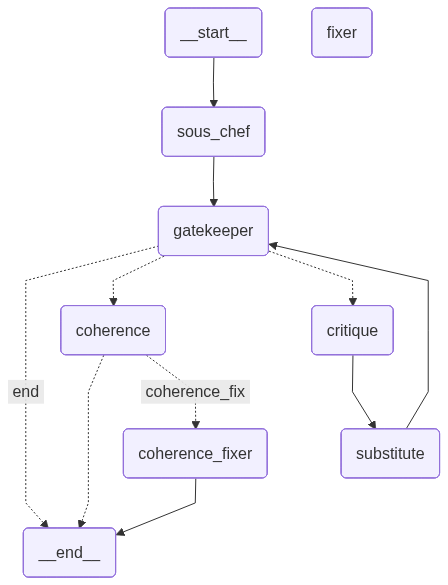

In [6]:
from IPython.display import Image, display

def visualize_graph(graph_app):
    try:
        # Generate the graph as a PNG using Mermaid.ink
        display(Image(graph_app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Could not visualize graph: {e}")
        print("\nFallback (Mermaid Text):")
        print(graph_app.get_graph().draw_mermaid())

# Usage:
# Assuming 'app' is your compiled graph from create_dishcovery_graph(agent_system)
visualize_graph(graph_app)